# Deteksi Kesenjangan Kompetensi dan Personalisasi Rencana Pengembangan Karir Menggunakan AI
## 1. Project Overview

### 1.1 Business Understanding

Pasar kerja berkembang dengan kecepatan yang belum pernah terjadi sebelumnya didorong oleh disrupsi teknologi, normalisasi kerja jarak jauh, dan maraknya peran yang didukung AI. Organisasi-organisasi berupaya menjawab:

- *Keterampilan apa yang paling diminati dalam perekrutan saat ini?*
- *Industri mana yang memimpin dalam adopsi keterampilan?*
- *Bagaimana proses akuisisi talenta harus beradaptasi dengan pola permintaan yang terus berubah?*

Proyek ini mengembangkan **Deteksi Kesenjangan Kompetensi dan Personalisasi Rencana Pengembangan Karier Menggunakan AI** yang mengubah data lowongan kerja mentah dari LinkedIn menjadi wawasan tenaga kerja yang dapat ditindaklanjuti dengan menggabungkan NLP, Named Entity Recognition (NER), analisis tren keterampilan, dan rekomendasi karier.

---

### 1.2 Project Objectives

| # | Objective | Output |
|---|-----------|--------|
| 1 | Mengidentifikasi keterampilan yang sangat diminati dan sedang berkembang di berbagai sektor industri | `emerging_skills.csv` |
| 2 | Mengekstrak keterampilan dari deskripsi pekerjaan yang tidak terstruktur melalui NER | NER-ready SkillSpan dataset |
| 3 | Build skill demand & trend analysis from posting data | `skill_trend_timeseries.csv` |
| 4 | Membuat analisis permintaan dan tren keterampilan berdasarkan data lowongan kerja | `career_transition_dataset.csv` |
| 5 | Menyusun analisis tenaga kerja tingkat industri | `industry_skill_trend.csv` |

---

### 1.3 Business Questions

1. **Keterampilan apa saja yang paling diminati saat ini?**
2. **Sektor industri mana saja yang paling gencar mengadopsi keterampilan teknologi?**
3. **Bagaimana distribusi gaji berdasarkan jabatan dan tingkat pengalaman?**
4. **Jabatan apa saja yang memiliki potensi transisi karier tertinggi?**
5. **Bagaimana distribusi geografis dan kerja jarak jauh untuk jabatan dengan gaji tinggi?**


## 2. Import Libraries

All dependencies imported upfront: **core → data → visualization → NLP → ML**.

In [1]:
# ── Core ──────────────────────────────────────────────────────────────────────
import os, re, json, warnings, logging
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations

# ── Data ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── NLP ───────────────────────────────────────────────────────────────────────
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.decomposition import TruncatedSVD

# ── A/B TESTING ──────────────────────────────────────────────────────────
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, shapiro, levene
import itertools

# ── Configuration ─────────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

for resource in ["punkt", "stopwords", "punkt_tab"]:
    nltk.download(resource, quiet=True)

# ── Plot theme ─────────────────────────────────────────────────────────────────
PALETTE_MAIN   = "#2563EB"
PALETTE_ACCENT = "#F59E0B"
PALETTE_NEG    = "#EF4444"
PALETTE_POS    = "#10B981"
PALETTE_SEQ    = "Blues_d"

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
})


## 3. Data Loading

All datasets loaded once into a centralized registry. Paths are parameterized for portability.

In [3]:
# lokasi file dataset
DATA_DIR = Path("dataset/use_dataset")
SKILLSPAN_DIR = DATA_DIR / "skillspan"

def load_csv(filename: str) -> pd.DataFrame:
    path = DATA_DIR / filename
    data = pd.read_csv(path, low_memory=False)
    print(f"{filename}: {data.shape[0]:,} baris, {data.shape[1]} kolom")
    return data

def load_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open(encoding="utf-8") as file:
        for line in file:
            if line.strip():
                rows.append(json.loads(line))

    data = pd.DataFrame(rows)
    print(f"{path.name}: {len(data):,} baris")
    return data

# data utama
postings_raw = load_csv("postings.csv")
skills_raw = load_csv("skills.csv")
job_skills_raw = load_csv("all_job_post.csv")
companies_raw = load_csv("companies.csv")
industries_raw = load_csv("industries.csv")
job_industries_raw = load_csv("job_industries.csv")
related_skilss_raw = load_csv("related_skills.csv")

# data NER SkillSpan
skillspan_train = load_jsonl(SKILLSPAN_DIR / "train.json")
skillspan_dev = load_jsonl(SKILLSPAN_DIR / "dev.json")
skillspan_test = load_jsonl(SKILLSPAN_DIR / "test.json")

print("\nRingkasan dataset:")
print(f"  {'Dataset':<22} {'Rows':>8}  {'Cols':>5}")
print("  " + "-"*40)
for name, df in [
    ("postings", postings_raw),
    ("skills", skills_raw),
    ("job_skills", job_skills_raw),
    ("companies", companies_raw),
    ("industries", industries_raw),
    ("job_industries", job_industries_raw),
    ("skillspan_train", skillspan_train),
    ("skillspan_dev", skillspan_dev),
    ("skillspan_test", skillspan_test),
]:
    print(f"  {name:<22} {df.shape[0]:>8,}  {df.shape[1]:>5}")


postings.csv: 123,849 baris, 31 kolom
skills.csv: 35 baris, 2 kolom
all_job_post.csv: 1,167 baris, 5 kolom
companies.csv: 24,473 baris, 10 kolom
industries.csv: 422 baris, 2 kolom
job_industries.csv: 164,808 baris, 2 kolom
related_skills.csv: 28,934 baris, 11 kolom
train.json: 4,800 baris
dev.json: 3,174 baris
test.json: 3,569 baris

Ringkasan dataset:
  Dataset                    Rows   Cols
  ----------------------------------------
  postings                123,849     31
  skills                       35      2
  job_skills                1,167      5
  companies                24,473     10
  industries                  422      2
  job_industries          164,808      2
  skillspan_train           4,800      5
  skillspan_dev             3,174      5
  skillspan_test            3,569      5


### 3.1 Dataset Sample Views

In [4]:
print("="*70)
print("POSTINGS — First 3 rows (key columns)")
print("="*70)
display(postings_raw[["job_id","title","location","formatted_experience_level",
                       "normalized_salary","work_type","listed_time"]].head(3))

print("\n" + "="*70)
print("SKILLS")
print("="*70)
display(skills_raw.head(10))

print("\n" + "="*70)
print("JOB_SKILLS — First 5 rows")
print("="*70)
display(job_skills_raw.head(5))

print("\n" + "="*70)
print("SKILLSPAN TRAIN — First 3 records")
print("="*70)
display(skillspan_train.head(3))


POSTINGS — First 3 rows (key columns)


,job_id,title,location,formatted_experience_level,normalized_salary,work_type,listed_time
0,921716,Marketing Coordinator,"Princeton, NJ",NaN,"38,480.00",FULL_TIME,"1,713,397,508,000.00"
1,1829192,Mental Health Therapist/Counselor,"Fort Collins, CO",NaN,"83,200.00",FULL_TIME,"1,712,857,887,000.00"
2,10998357,Assitant Restaurant Manager,"Cincinnati, OH",NaN,"55,000.00",FULL_TIME,"1,713,277,614,000.00"



SKILLS


,skill_abr,skill_name
0,ART,Art/Creative
1,DSGN,Design
2,ADVR,Advertising
3,PRDM,Product Management
4,DIST,Distribution
5,EDU,Education
6,TRNG,Training
7,PRJM,Project Management
8,CNSL,Consulting
9,PRCH,Purchasing



JOB_SKILLS — First 5 rows


,job_id,category,job_title,job_description,job_skill_set
0,3902668440,HR,Sr Human Resource Generalist,"SUMMARY\nTHE SR. HR GENERALIST PROVIDES HR EXPERTISE ACROSS VARIOUS FUNCTIONS INCLUDING EMPLOYEE RELATIONS, TALENT A...","['employee relations', 'talent acquisition', 'performance management', 'compensation and benefits', 'employment laws..."
1,3905823748,HR,Human Resources Manager,BE PART OF A STELLAR TEAM AT YSB AS THE MANAGER OF HUMAN RESOURCES. JOIN US AS YSB ENTERS A NEW AND VIBRANT ERA WITH...,"['Talent Acquisition', 'Employee Performance Management', 'Legal Compliance', 'Payroll Processing', 'Microsoft Offic..."
2,3905854799,HR,Director of Human Resources,OUR CLIENT IS A THRIVING ORGANIZATION OFFERING A UNIQUE OPPORTUNITY FOR A DIRECTOR OF HUMAN RESOURCES TO JOIN ITS DY...,"['Human Resources Management', 'Recruitment', 'Employee Relations', 'Performance Management', 'Compliance with Labor..."
3,3905834061,HR,Chief Human Resources Officer,JOB TITLE: CHIEF HUMAN RESOURCES OFFICER (CHRO)INDUSTRY: ENTERTAINMENT & MEDIA \nJOB DESCRIPTION:EAST 57TH STREET PA...,"['talent management', 'organizational development', 'HR compliance', 'HR technology systems', 'data-driven HR analyt..."
4,3906250451,HR,Human Resources Generalist (Hybrid Role),DESCRIPTION\n\n WHO WE ARE \n\nAVI-SPL IS A DIGITAL ENABLEMENT SOLUTIONS PROVIDER WHO TRANSFORMS HOW PEOPLE AND TECH...,"['Microsoft Office', 'Data analysis', 'Employee onboarding', 'Strategic thinking', 'Problem solving', 'Time manageme..."



SKILLSPAN TRAIN — First 3 records


,idx,tokens,tags_skill,tags_knowledge,source
0,1,"[Senior, QA, Engineer, (, m/f/d, ), <ORGANIZATION>]","[O, O, O, O, O, O, O]","[O, O, O, O, O, O, O]",tech
1,1,"[<ADDRESS>, <ADDRESS>, <ADDRESS>, <ADDRESS>, <LOCATION>]","[O, O, O, O, O]","[O, O, O, O, O]",tech
2,1,"[Date, posted:, 2021-07-14]","[O, O, O]","[O, O, O]",tech


## 4. Data Understanding

Systematic profiling of each dataset — structure, quality gaps, and relational integrity.

### 4.1 Dataset Overview

In [6]:
def dataset_overview(df: pd.DataFrame, name: str) -> pd.DataFrame:
    profile = pd.DataFrame({
        "dtype":        df.dtypes.astype(str),
        "null_count":   df.isnull().sum(),
        "null_pct":     (df.isnull().mean() * 100).round(2),
        "unique_count": df.nunique(),
        "sample":       [df[c].dropna().iloc[0] if df[c].notna().any() else "—" for c in df.columns],
    })
    print(f"\n{'='*65}")
    print(f"  {name.upper()} — Shape: {df.shape}")
    print(f"{'='*65}")
    display(profile)
    return profile

_ = dataset_overview(postings_raw,    "postings")
_ = dataset_overview(skills_raw,      "skills")
_ = dataset_overview(job_skills_raw,  "job_skills")
_ = dataset_overview(companies_raw,   "companies")
_ = dataset_overview(industries_raw,  "industries")



  POSTINGS — Shape: (123849, 31)


,dtype,null_count,null_pct,unique_count,sample
job_id,int64,0,0.00,123849,921716
company_name,object,1719,1.39,24428,Corcoran Sawyer Smith
title,object,0,0.00,72521,Marketing Coordinator
description,object,7,0.01,107827,Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing Coordinator with some...
max_salary,float64,94056,75.94,5321,20.00
pay_period,object,87776,70.87,5,HOURLY
location,object,0,0.00,8526,"Princeton, NJ"
company_id,float64,1717,1.39,24474,"2,774,458.00"
views,float64,1689,1.36,684,20.00
med_salary,float64,117569,94.93,1417,350.00



  SKILLS — Shape: (35, 2)


,dtype,null_count,null_pct,unique_count,sample
skill_abr,object,0,0.00,35,ART
skill_name,object,0,0.00,35,Art/Creative



  JOB_SKILLS — Shape: (213768, 2)


,dtype,null_count,null_pct,unique_count,sample
job_id,int64,0,0.00,126807,3884428798
skill_abr,object,0,0.00,35,MRKT



  COMPANIES — Shape: (24473, 10)


,dtype,null_count,null_pct,unique_count,sample
company_id,int64,0,0.00,24473,1009
name,object,1,0.00,24428,IBM
description,object,297,1.21,24164,"At IBM, we do more than work. We create. We create as technologists, developers, and engineers. We create with our p..."
company_size,float64,2774,11.33,7,7.00
state,object,22,0.09,788,NY
country,object,0,0.00,81,US
city,object,1,0.00,4124,"Armonk, New York"
zip_code,object,28,0.11,7779,10504
address,object,22,0.09,19476,International Business Machines Corp.
url,object,0,0.00,24473,https://www.linkedin.com/company/ibm



  INDUSTRIES — Shape: (422, 2)


,dtype,null_count,null_pct,unique_count,sample
industry_id,int64,0,0.00,422,1
industry_name,object,34,8.06,388,Defense and Space Manufacturing


### 4.2 Missing Values Analysis

In [7]:
def cek_missing(df: pd.DataFrame, nama_data: str) -> pd.DataFrame:
    jumlah = df.isna().sum()
    persen = (df.isna().mean() * 100).round(2)

    hasil = pd.DataFrame({
        "dataset": nama_data,
        "kolom": jumlah.index,
        "missing_count": jumlah.values,
        "missing_pct": persen.values,
    })

    hasil = hasil[hasil["missing_count"] > 0]
    return hasil.sort_values("missing_pct", ascending=False).reset_index(drop=True)

missing_values = pd.concat([
    cek_missing(postings_raw, "postings"),
    cek_missing(companies_raw, "companies"),
], ignore_index=True)

missing_values


,dataset,kolom,missing_count,missing_pct
0,postings,closed_time,122776,99.13
1,postings,skills_desc,121410,98.03
2,postings,med_salary,117569,94.93
3,postings,remote_allowed,108603,87.69
4,postings,applies,100529,81.17
5,postings,max_salary,94056,75.94
6,postings,min_salary,94056,75.94
7,postings,pay_period,87776,70.87
8,postings,normalized_salary,87776,70.87
9,postings,compensation_type,87776,70.87


### 4.3 Duplicate Analysis

In [6]:
print("Duplicate Analysis")
print("-" * 55)
for name, df, key in [
    ("postings",       postings_raw,       "job_id"),
    ("job_skills",     job_skills_raw,     ["job_id","skill_abr"]),
    ("job_industries", job_industries_raw, ["job_id","industry_id"]),
    ("companies",      companies_raw,      "company_id"),
]:
    total_dups = df.duplicated().sum()
    key_dups   = df.duplicated(subset=key).sum()
    print(f"  {name:<20} | full dups: {total_dups:>5,} | key dups: {key_dups:>5,}")


Duplicate Analysis
-------------------------------------------------------
  postings             | full dups:     0 | key dups:     0
  job_skills           | full dups:     0 | key dups:     0
  job_industries       | full dups:     0 | key dups:     0
  companies            | full dups:     0 | key dups:     0


### 4.4 Relational Integrity — Join Coverage

In [7]:
post_ids     = set(postings_raw["job_id"])
js_ids       = set(job_skills_raw["job_id"])
ji_ids       = set(job_industries_raw["job_id"])
company_ids  = set(companies_raw["company_id"])
posting_cids = set(postings_raw["company_id"].dropna().astype(int))

print("Relational Coverage")
print("-" * 60)
print(f"  job_skills    → postings  : {len(js_ids & post_ids):>6,} / {len(js_ids):>6,} ({len(js_ids & post_ids)/len(js_ids)*100:.1f}%)")
print(f"  job_industries→ postings  : {len(ji_ids & post_ids):>6,} / {len(ji_ids):>6,} ({len(ji_ids & post_ids)/len(ji_ids)*100:.1f}%)")
print(f"  postings      → companies : {len(posting_cids & company_ids):>6,} / {len(posting_cids):>6,} ({len(posting_cids & company_ids)/len(posting_cids)*100:.1f}%)")

Relational Coverage
------------------------------------------------------------
  job_skills    → postings  : 122,096 / 126,807 (96.3%)
  job_industries→ postings  : 122,413 / 127,125 (96.3%)
  postings      → companies : 24,473 / 24,474 (100.0%)


## 5. Data Wrangling

Pipeline: **Gather → Assess → Clean → Transform → Validate**.
Minimum transformations — preserving natural language fidelity for NLP/NER.

### 5.1 Datetime Conversion & Temporal Consistency

In [8]:
# ── Timestamp columns: Unix ms → UTC datetime ─────────────────────────────────
TIMESTAMP_COLS = ["original_listed_time", "listed_time", "expiry", "closed_time"]
postings = postings_raw.copy()

for col in TIMESTAMP_COLS:
    postings[col] = pd.to_datetime(postings[col], unit="ms", utc=True, errors="coerce")

# ── Derived temporal features ──────────────────────────────────────────────────
postings["listed_year"]  = postings["listed_time"].dt.year
postings["listed_month"] = postings["listed_time"].dt.month
postings["listed_week"]  = postings["listed_time"].dt.to_period("W")
postings["listed_ym"]    = postings["listed_time"].dt.to_period("M")
postings["posting_duration_days"] = (
    (postings["expiry"] - postings["listed_time"]).dt.total_seconds() / 86_400
)

# ── Temporal consistency checks ───────────────────────────────────────────────
checks = {
    "expiry < listed_time":      (postings["expiry"] < postings["listed_time"]).sum(),
    "closed_time < listed_time": (postings["closed_time"] < postings["listed_time"]).sum(),
    "negative duration":         (postings["posting_duration_days"] < 0).sum(),
}
print("Temporal Consistency Checks")
print("-" * 50)
for check, count in checks.items():
    status = "✅" if count == 0 else "⚠️ "
    print(f"  {status} {check:<35} {count:>5,}")

print(f"\nDate range : {postings['listed_time'].min().date()} → {postings['listed_time'].max().date()}")
print(f"Unique months : {postings['listed_ym'].nunique()}")
print(f"Unique weeks  : {postings['listed_week'].nunique()}")

Temporal Consistency Checks
--------------------------------------------------
  ✅ expiry < listed_time                    0
  ✅ closed_time < listed_time               0
  ✅ negative duration                       0

Date range : 2024-03-24 → 2024-04-20
Unique months : 2
Unique weeks  : 4


### 5.2 Cleaning — Postings

In [9]:
def clean_postings(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    # Salary: clip obvious outliers
    out["normalized_salary"] = out["normalized_salary"].clip(upper=5_000_000)
    # String columns: strip whitespace, preserve casing for NER
    for col in ["title","location","company_name","formatted_experience_level","work_type"]:
        out[col] = out[col].astype(str).str.strip().replace("nan", np.nan)
    # Remote: fill null with 0 (not explicitly remote)
    out["remote_allowed"] = out["remote_allowed"].fillna(0).astype(int)
    # Experience level: standardize null label
    out["formatted_experience_level"] = (
        out["formatted_experience_level"]
        .replace({"nan": "Not Specified", "": "Not Specified"})
        .fillna("Not Specified")
    )
    return out

postings = clean_postings(postings)
print(f"Postings after cleaning : {postings.shape}")
print(f"  Rows with salary      : {postings['normalized_salary'].notna().sum():,}")
print(f"  Remote postings       : {postings['remote_allowed'].sum():,}")


Postings after cleaning : (123849, 36)
  Rows with salary      : 36,073
  Remote postings       : 15,246


### 5.3 Master Dataset Assembly

In [10]:
def build_master(postings, job_skills, skills, job_industries, industries, companies):
    js_named = (
        job_skills.merge(skills, on="skill_abr", how="left")
        .groupby("job_id")
        .agg(skill_list=("skill_name", list), skill_abr_list=("skill_abr", list))
        .reset_index()
    )
    ji_named = (
        job_industries.merge(industries, on="industry_id", how="left")
        .groupby("job_id")
        .agg(industry_list=("industry_name", list))
        .reset_index()
    )
    master = (
        postings
        .merge(js_named,  on="job_id", how="left")
        .merge(ji_named,  on="job_id", how="left")
        .merge(
            companies[["company_id","name","company_size","state","country","city"]]
                     .rename(columns={"name": "company_full_name"}),
            on="company_id", how="left"
        )
    )
    return master

master = build_master(postings, job_skills_raw, skills_raw,
                      job_industries_raw, industries_raw, companies_raw)

print(f"Master dataset shape      : {master.shape}")
print(f"Jobs with ≥1 skill      : {master['skill_list'].notna().sum():,}")
print(f"Jobs with ≥1 industry   : {master['industry_list'].notna().sum():,}")
display(master[["job_id","title","skill_list","industry_list",
                "normalized_salary","listed_ym"]].head(3))


Master dataset shape      : (123849, 44)
Jobs with ≥1 skill      : 122,096
Jobs with ≥1 industry   : 122,413


,job_id,title,skill_list,industry_list,normalized_salary,listed_ym
0,921716,Marketing Coordinator,"[Marketing, Sales]",[Real Estate],"38,480.00",2024-04
1,1829192,Mental Health Therapist/Counselor,[Health Care Provider],NaN,"83,200.00",2024-04
2,10998357,Assitant Restaurant Manager,"[Management, Manufacturing]",[Restaurants],"55,000.00",2024-04


## 6. Exploratory Data Analysis (EDA)

Systematic exploration across five dimensions: **Skills · Industry · Company · Salary · Role Distribution**.

### 6.1 Top Skills by Frequency

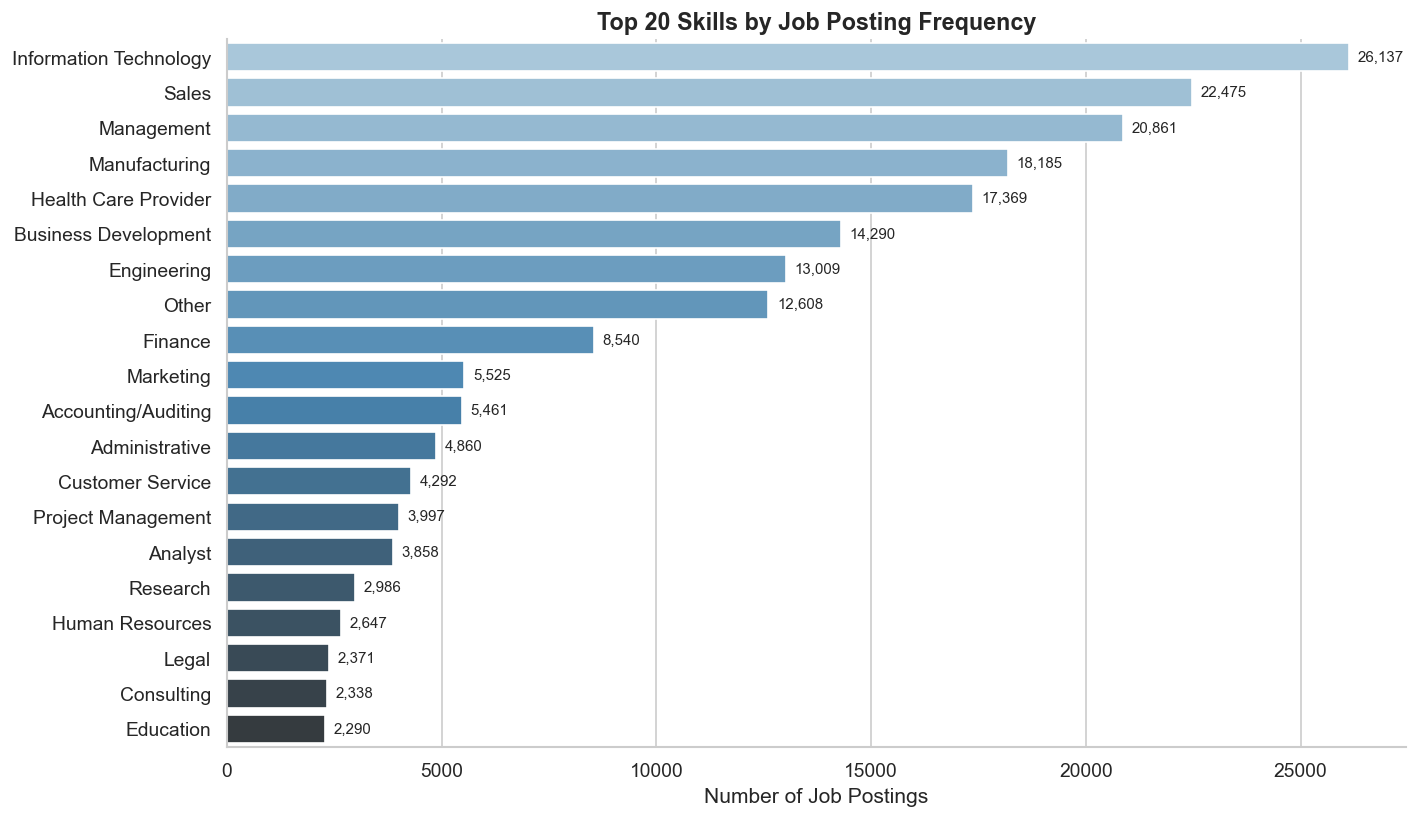


Insight: Keterampilan teratas mencerminkan tingginya permintaan akan kompetensi di bidang manajemen dan TI.


In [11]:
skill_counts = (
    job_skills_raw.merge(skills_raw, on="skill_abr", how="left")
    ["skill_name"].value_counts()
    .reset_index()
    .rename(columns={"skill_name": "skill", "count": "frequency"})
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=skill_counts.head(20), x="frequency", y="skill",
            palette=sns.color_palette(PALETTE_SEQ, 20), ax=ax)
ax.set_title("Top 20 Skills by Job Posting Frequency", fontweight="bold", fontsize=14)
ax.set_xlabel("Number of Job Postings"); ax.set_ylabel("")
for bar in ax.patches:
    ax.text(bar.get_width()+200, bar.get_y()+bar.get_height()/2,
            f"{int(bar.get_width()):,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print("\nInsight: Keterampilan teratas mencerminkan tingginya permintaan akan kompetensi di bidang manajemen dan TI.")


### 6.2 Top Industries

In [12]:
industry_counts = (
    job_industries_raw.merge(industries_raw, on="industry_id", how="left")
    ["industry_name"].value_counts().head(15)
    .reset_index().rename(columns={"industry_name":"industry","count":"job_count"})
)
fig = px.bar(industry_counts, x="job_count", y="industry", orientation="h",
             color="job_count", color_continuous_scale="Blues",
             title="Top 15 Industries by Job Posting Volume",
             labels={"job_count":"Job Postings","industry":""})
fig.update_layout(yaxis=dict(autorange="reversed"), coloraxis_showscale=False,
                  plot_bgcolor="white", height=500)
fig.show()

print("\nInsight: Layanan Teknologi & TI mendominasi, disusul oleh sektor Keuangan dan Kesehatan.")



Insight: Layanan Teknologi & TI mendominasi, disusul oleh sektor Keuangan dan Kesehatan.


### 6.3 Top Companies by Posting Volume

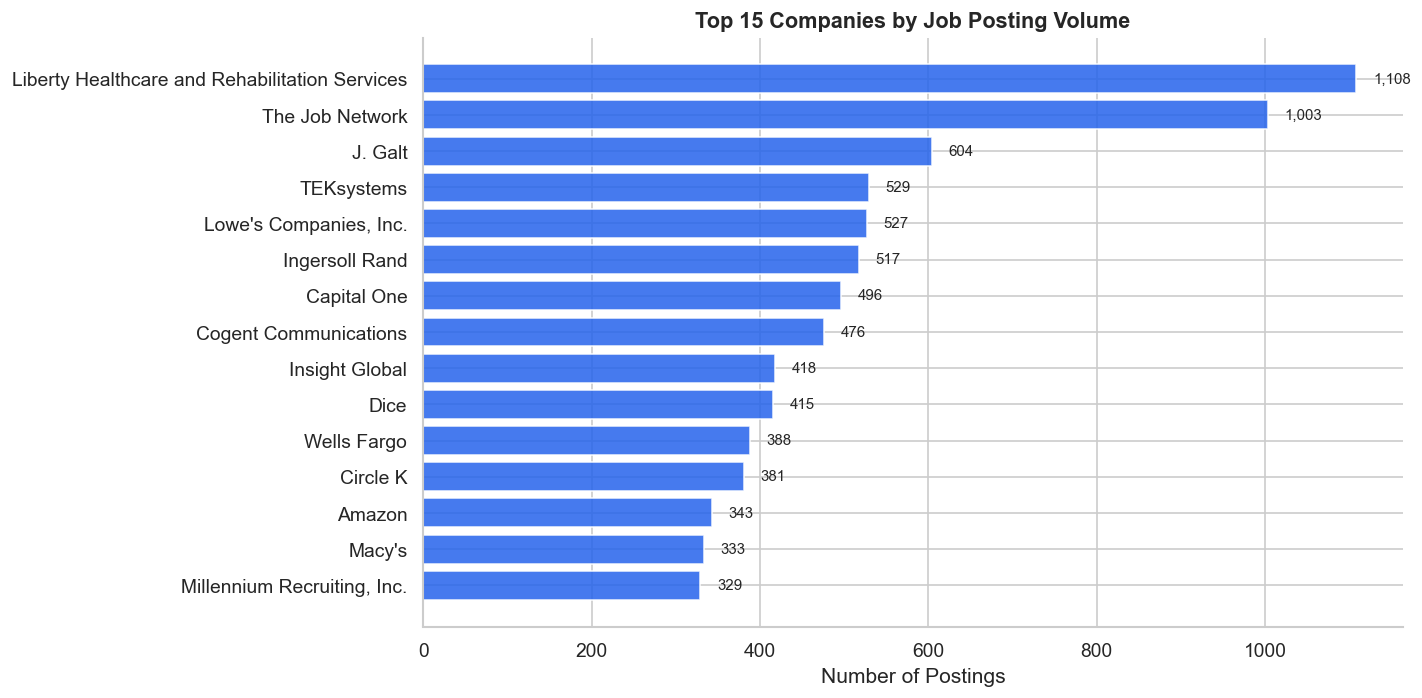

In [13]:
top_companies = (
    postings["company_name"].value_counts().head(15)
    .reset_index().rename(columns={"company_name":"company","count":"postings"})
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_companies["company"], top_companies["postings"],
               color=PALETTE_MAIN, alpha=0.85)
ax.set_title("Top 15 Companies by Job Posting Volume", fontweight="bold", fontsize=13)
ax.set_xlabel("Number of Postings"); ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2,
            f"{int(bar.get_width()):,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

### 6.4 Salary Distribution Analysis

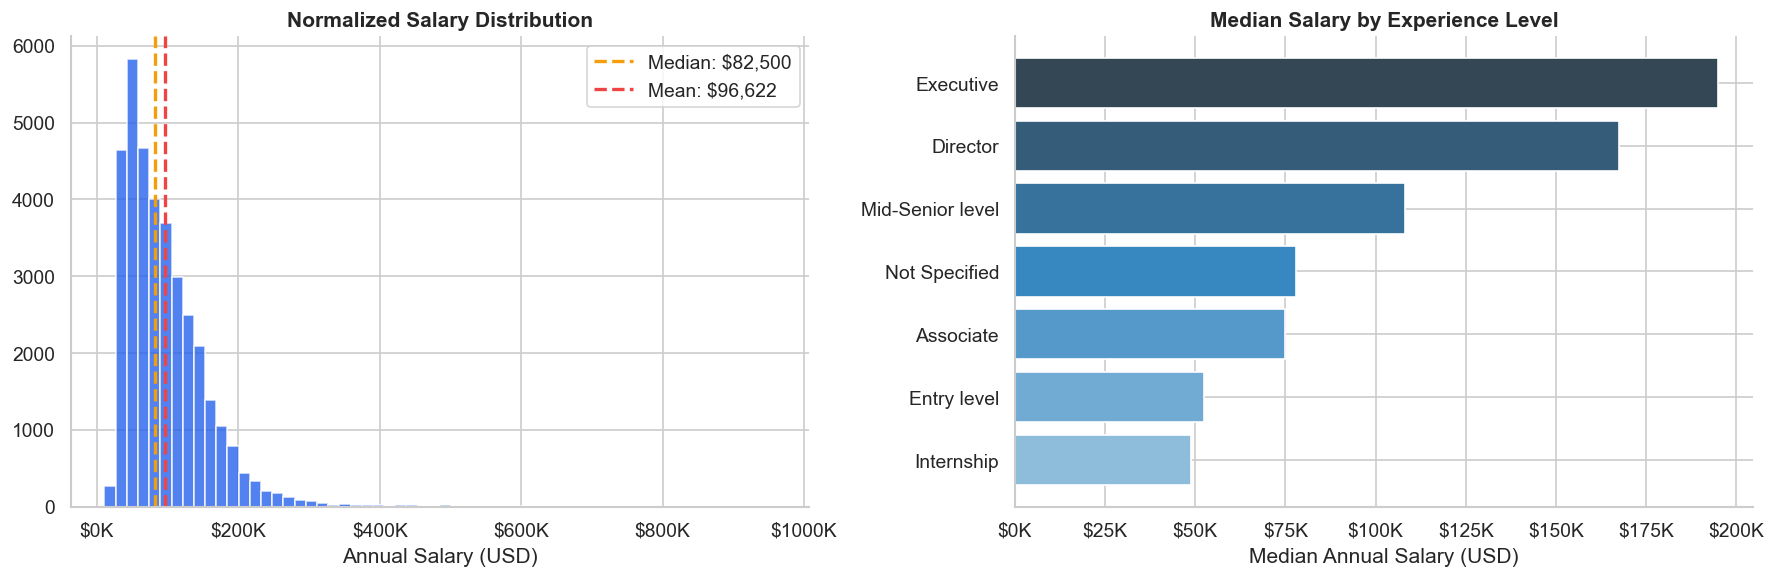


Salary Statistics:
   Median : $    82,500
   Mean   : $    96,622
   P25    : $    52,044
   P75    : $   125,000


In [14]:
sal = postings["normalized_salary"].dropna()
sal = sal[(sal > 10_000) & (sal < 1_000_000)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(sal, bins=60, color=PALETTE_MAIN, alpha=0.8, edgecolor="white")
axes[0].axvline(sal.median(), color=PALETTE_ACCENT, lw=2, ls="--",
                label=f"Median: ${sal.median():,.0f}")
axes[0].axvline(sal.mean(), color=PALETTE_NEG, lw=2, ls="--",
                label=f"Mean: ${sal.mean():,.0f}")
axes[0].set_title("Normalized Salary Distribution", fontweight="bold")
axes[0].set_xlabel("Annual Salary (USD)"); axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1000:.0f}K"))

exp_sal = (
    postings.dropna(subset=["normalized_salary","formatted_experience_level"])
    .query("normalized_salary > 10_000 and normalized_salary < 1_000_000")
    .groupby("formatted_experience_level")["normalized_salary"]
    .median().sort_values().reset_index()
)
axes[1].barh(exp_sal["formatted_experience_level"], exp_sal["normalized_salary"],
             color=sns.color_palette("Blues_d", len(exp_sal)))
axes[1].set_title("Median Salary by Experience Level", fontweight="bold")
axes[1].set_xlabel("Median Annual Salary (USD)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1000:.0f}K"))

plt.tight_layout()
plt.show()

print(f"\nSalary Statistics:")
print(f"   Median : ${sal.median():>10,.0f}")
print(f"   Mean   : ${sal.mean():>10,.0f}")
print(f"   P25    : ${sal.quantile(0.25):>10,.0f}")
print(f"   P75    : ${sal.quantile(0.75):>10,.0f}")


### 6.5 Role Distribution & Experience Level

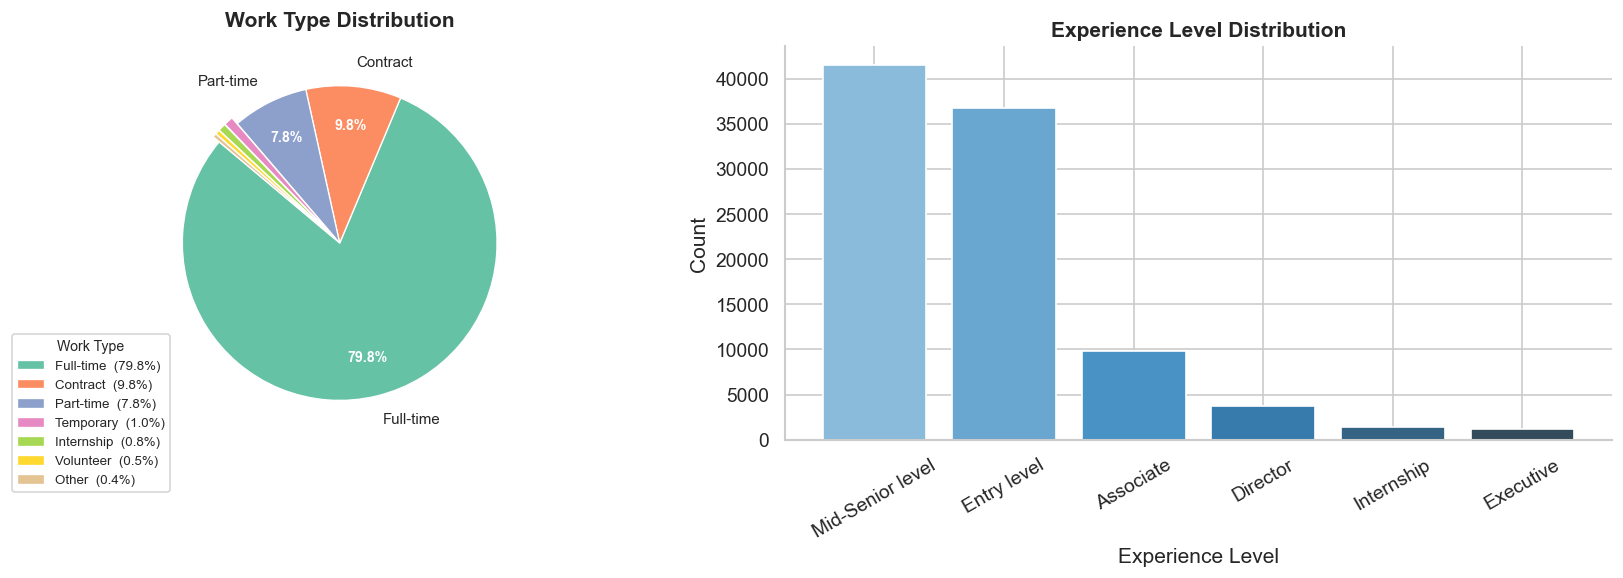

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

wt_counts = postings["formatted_work_type"].value_counts()

# ── Pisahkan label: besar di pie, kecil di legend ─────────────────────────────
THRESHOLD   = 3.0   # slice < 3% → tidak diberi label langsung di pie
total       = wt_counts.sum()
pct_values  = wt_counts.values / total * 100

labels_pie  = [
    label if pct >= THRESHOLD else ""
    for label, pct in zip(wt_counts.index, pct_values)
]

# ── Custom autopct: hanya tampil jika slice cukup besar ───────────────────────
def autopct_filter(pct):
    return f"{pct:.1f}%" if pct >= THRESHOLD else ""

# ── Explode slice kecil agar tidak menumpuk ───────────────────────────────────
explode = [0.05 if pct < THRESHOLD else 0 for pct in pct_values]

wedges, texts, autotexts = axes[0].pie(
    wt_counts.values,
    labels      = labels_pie,
    autopct     = autopct_filter,
    colors      = sns.color_palette("Set2", len(wt_counts)),
    startangle  = 140,
    explode     = explode,
    pctdistance = 0.75,     # persentase lebih ke tengah
    labeldistance = 1.15,   # label lebih jauh dari tepi
    wedgeprops  = dict(linewidth=0.8, edgecolor="white"),
)

# ── Styling teks ──────────────────────────────────────────────────────────────
for text in texts:
    text.set_fontsize(9)
for autotext in autotexts:
    autotext.set_fontsize(8.5)
    autotext.set_fontweight("bold")
    autotext.set_color("white")

# ── Legend untuk semua kategori (termasuk slice kecil) ───────────────────────
axes[0].legend(
    wedges,
    [f"{label}  ({pct:.1f}%)" for label, pct in zip(wt_counts.index, pct_values)],
    title          = "Work Type",
    loc            = "lower left",
    bbox_to_anchor = (-0.35, -0.15),
    fontsize       = 8,
    title_fontsize = 8.5,
    framealpha     = 0.8,
)
axes[0].set_title("Work Type Distribution", fontweight="bold", pad=12)

exp_counts = postings["formatted_experience_level"].value_counts()
exp_counts = exp_counts[exp_counts.index != "Not Specified"]
axes[1].bar(exp_counts.index, exp_counts.values,
            color=sns.color_palette(PALETTE_SEQ, len(exp_counts)))
axes[1].set_title("Experience Level Distribution", fontweight="bold")
axes[1].set_xlabel("Experience Level"); axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


### 6.6 Remote Work Analysis

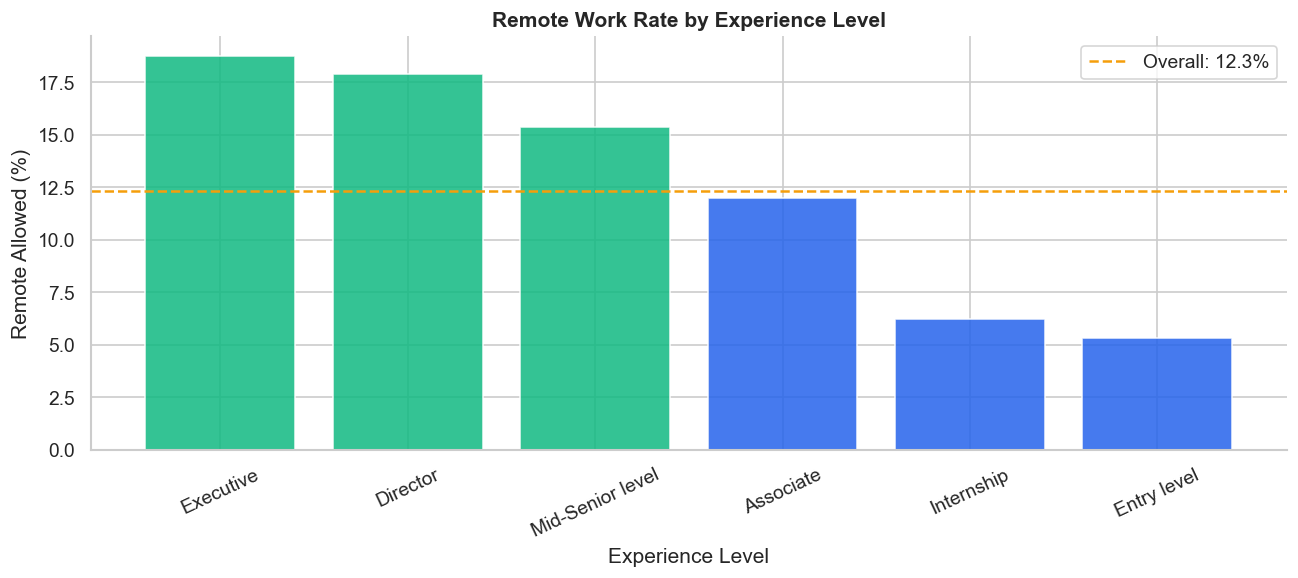

In [16]:
remote_pct = postings["remote_allowed"].mean() * 100
remote_by_exp = (
    postings.groupby("formatted_experience_level")["remote_allowed"]
    .mean().mul(100).sort_values(ascending=False).reset_index()
    .query("formatted_experience_level != 'Not Specified'")
)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(remote_by_exp["formatted_experience_level"],
              remote_by_exp["remote_allowed"],
              color=[PALETTE_POS if v > remote_pct else PALETTE_MAIN
                     for v in remote_by_exp["remote_allowed"]], alpha=0.85)
ax.axhline(remote_pct, color=PALETTE_ACCENT, ls="--", lw=1.5,
           label=f"Overall: {remote_pct:.1f}%")
ax.set_title("Remote Work Rate by Experience Level", fontweight="bold")
ax.set_ylabel("Remote Allowed (%)"); ax.set_xlabel("Experience Level")
ax.tick_params(axis="x", rotation=25); ax.legend()
plt.tight_layout()
plt.show()


### 6.7 Skill Co-occurrence Analysis

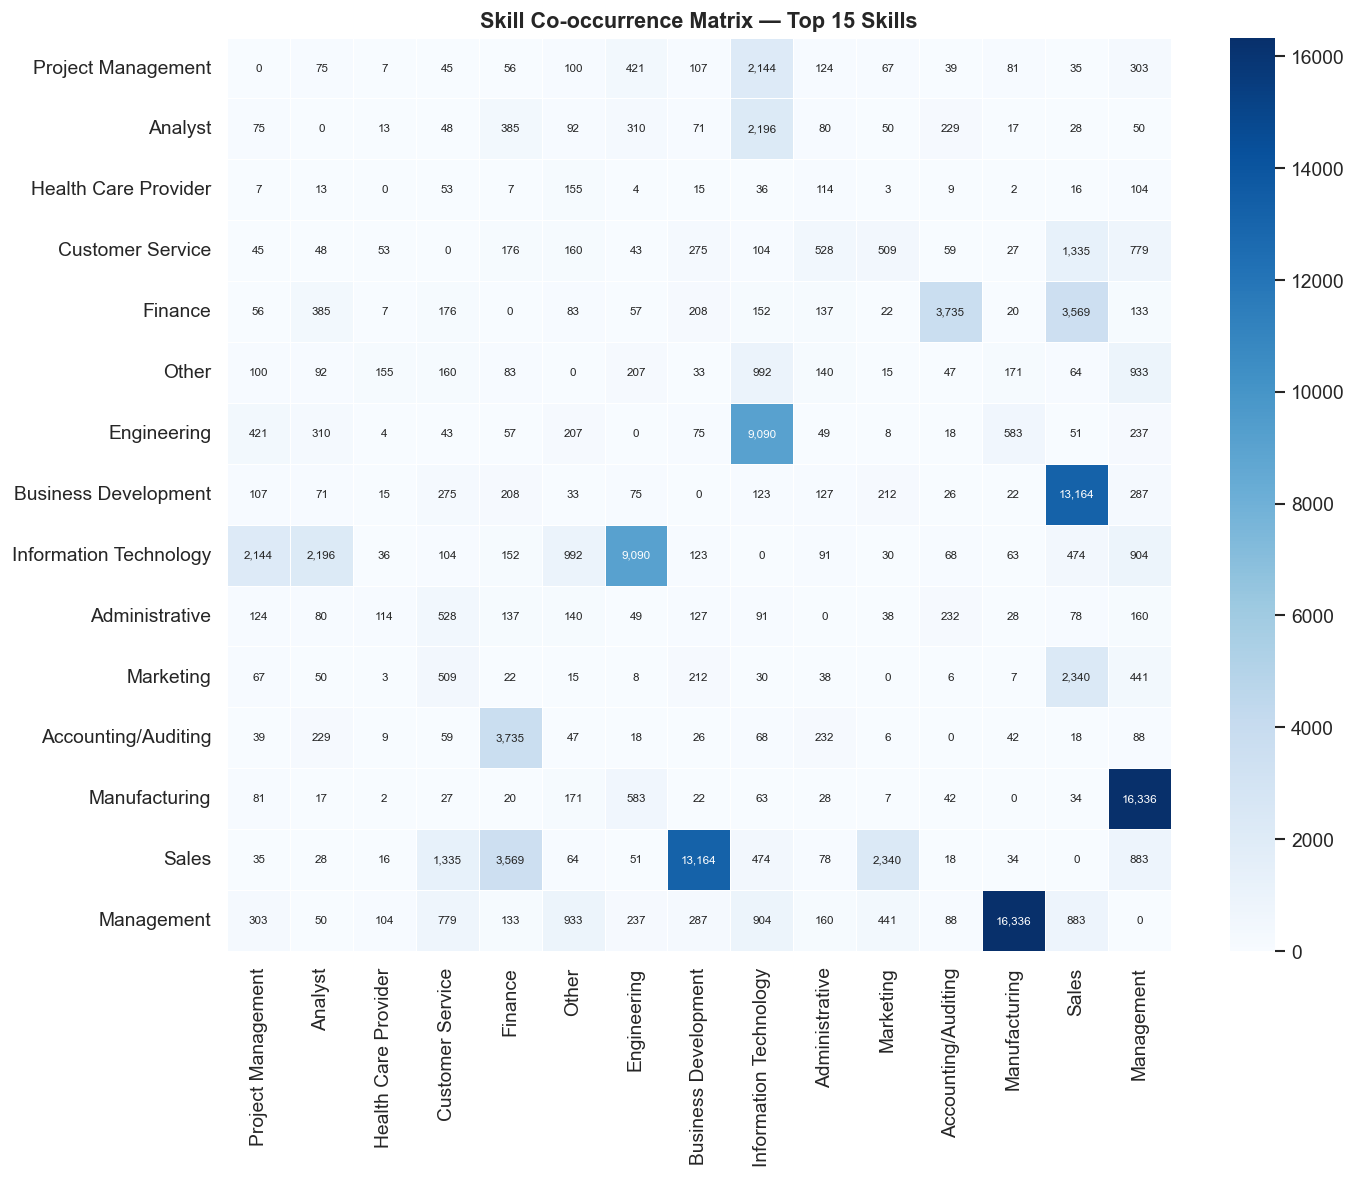


Pasangan dengan tingkat kemunculan bersama yang tinggi menandakan adanya sinyal kunci terkait permintaan kompetensi terpadu dalam perancangan deskripsi jabatan.


In [17]:
TOP_N_COOC   = 15
top_skills_list = skill_counts.head(TOP_N_COOC)["skill"].tolist()
top_abrs = skills_raw[skills_raw["skill_name"].isin(top_skills_list)]["skill_abr"].tolist()

job_skill_pivot = job_skills_raw[job_skills_raw["skill_abr"].isin(top_abrs)].drop_duplicates()

cooc = defaultdict(int)
for job_id, group in job_skill_pivot.groupby("job_id")["skill_abr"]:
    for a, b in combinations(sorted(group), 2):
        cooc[(a, b)] += 1

abr_to_name  = dict(zip(skills_raw["skill_abr"], skills_raw["skill_name"]))
cooc_matrix  = pd.DataFrame(0, index=top_abrs, columns=top_abrs)
for (a, b), cnt in cooc.items():
    if a in cooc_matrix.index and b in cooc_matrix.columns:
        cooc_matrix.loc[a, b] = cnt
        cooc_matrix.loc[b, a] = cnt
cooc_matrix.index   = [abr_to_name.get(x, x) for x in cooc_matrix.index]
cooc_matrix.columns = [abr_to_name.get(x, x) for x in cooc_matrix.columns]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cooc_matrix, annot=True, fmt=",d", cmap="Blues",
            linewidths=0.3, ax=ax, annot_kws={"size": 7})
ax.set_title("Skill Co-occurrence Matrix — Top 15 Skills", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

print("\nPasangan dengan tingkat kemunculan bersama yang tinggi menandakan adanya sinyal kunci terkait permintaan kompetensi terpadu dalam perancangan deskripsi jabatan.")


## 7. Persiapan NLP

**Prasunting ringan dan terarah** — mempertahankan struktur bahasa alami untuk kompatibilitas dengan model bahasa yang telah dilatih sebelumnya (LM) dan penyempurnaan NER.

> **Keputusan Desain:** Tidak ada pemotongan kata (stemming), lemmatisasi, atau pemetaan sinonim yang agresif.  
> Keragaman bentuk permukaan sangat penting untuk pelatihan dan generalisasi NER yang andal.

In [ ]:
STOP_WORDS = set(stopwords.words("english"))

def preprocess_light(text: str) -> dict:
    """
    Minimal NLP preprocessing. ALWAYS returns a dict — never a plain string.
    Preserves original casing for NER; provides lowercase copy for TF-IDF.
    """
    EMPTY = {"original": "", "normalized": "", "lowercase": "", "tokens": [], "token_count": 0}
    if not isinstance(text, str) or not text.strip():
        return EMPTY

    normalized = re.sub(r"\s+", " ", text).strip()
    normalized = re.sub(r"http\S+|www\.\S+", "", normalized)
    normalized = re.sub(r"\S+@\S+\.\S+", "", normalized)
    normalized = re.sub(r"\s+", " ", normalized).strip()

    lowercase = normalized.lower()
    tokens    = [t for t in word_tokenize(lowercase) if t.isalpha()]

    return {
        "original":    text.strip(),
        "normalized":  normalized,
        "lowercase":   lowercase,
        "tokens":      tokens,
        "token_count": len(tokens),
    }

# ── Verify on sample ──────────────────────────────────────────────────────────
sample = postings["description"].dropna().iloc[0]
out    = preprocess_light(sample)
print("NLP Preprocessing — Sample Output")
print("-" * 50)
print(f"  Token count : {out['token_count']}")
print(f"  First tokens: {out['tokens'][:15]}")
print(f"  Normalized  : {out['normalized'][:200]}...")


NLP Preprocessing — Sample Output
--------------------------------------------------
  Token count : 326
  First tokens: ['job', 'descriptiona', 'leading', 'real', 'estate', 'firm', 'in', 'new', 'jersey', 'is', 'seeking', 'an', 'administrative', 'marketing', 'coordinator']
  Normalized  : Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing Coordinator with some experience in graphic design. You will be working closely with our fun, kind, ambit...


In [20]:
print("Applying NLP preprocessing to job descriptions...")

# Apply ONCE per column, then unpack — avoids KeyError on empty-string returns
nlp_desc_series  = postings["description"].apply(preprocess_light)
nlp_skill_series = postings["skills_desc"].apply(preprocess_light)

desc_df  = pd.DataFrame(nlp_desc_series.tolist(),  index=postings.index)
skill_df = pd.DataFrame(nlp_skill_series.tolist(), index=postings.index)

postings["desc_normalized"]        = desc_df["normalized"]
postings["desc_lowercase"]         = desc_df["lowercase"]
postings["desc_tokens"]            = desc_df["tokens"]
postings["desc_token_count"]       = desc_df["token_count"]
postings["skills_desc_normalized"] = skill_df["normalized"]

print(f"Done.")
print(f"   Mean token count   : {postings['desc_token_count'].mean():.0f}")
print(f"   Median token count : {postings['desc_token_count'].median():.0f}")
print(f"   Empty descriptions : {(postings['desc_token_count'] == 0).sum():,}")

Applying NLP preprocessing to job descriptions...
Done.
   Mean token count   : 502
   Median token count : 457
   Empty descriptions : 14


## 8. NER Preparation

Preparing **SkillSpan** for Named Entity Recognition fine-tuning using **BIO tagging**.

### 8.1 BIO Tagging Scheme

| Tag | Meaning | Example |
|-----|---------|---------|
| `B-SKILL` | Beginning of skill entity | *Python* |
| `I-SKILL` | Continuation of skill entity | *programming* |
| `O` | Outside — not an entity | *experience* |
| `B-KNOWLEDGE` | Beginning of knowledge entity | *machine* |
| `I-KNOWLEDGE` | Continuation of knowledge entity | *learning* |

### 8.2 Entity Preservation Strategy

> Skill entities are often compound phrases (*"machine learning"*, *"project management"*).  
> Aggressive preprocessing fragments entities across token boundaries → degrades NER quality.  
> **Strategy:** Preserve original token casing · No synonym normalization · Keep placeholders (`<ORGANIZATION>`, `<LOCATION>`) as single tokens.


In [21]:
def profile_skillspan(df: pd.DataFrame, split_name: str) -> dict:
    all_skill_tags, all_know_tags = [], []
    skill_entities, know_entities = [], []
    total_tokens = 0

    for _, row in df.iterrows():
        tokens, skill_tags, know_tags = row["tokens"], row["tags_skill"], row["tags_knowledge"]
        total_tokens += len(tokens)
        all_skill_tags.extend(skill_tags); all_know_tags.extend(know_tags)

        for tag_list, entity_list in [(skill_tags, skill_entities), (know_tags, know_entities)]:
            current = []
            for tok, tag in zip(tokens, tag_list):
                if tag.startswith("B-"):
                    if current: entity_list.append(" ".join(current))
                    current = [tok]
                elif tag.startswith("I-") and current:
                    current.append(tok)
                else:
                    if current: entity_list.append(" ".join(current))
                    current = []
            if current: entity_list.append(" ".join(current))

    skill_tag_dist = Counter(all_skill_tags)
    know_tag_dist  = Counter(all_know_tags)
    return {
        "split": split_name, "sentences": len(df), "total_tokens": total_tokens,
        "skill_entities": len(skill_entities), "knowledge_entities": len(know_entities),
        "unique_skills":      len(set(skill_entities)),
        "unique_knowledge":   len(set(know_entities)),
        "skill_B_tags":  skill_tag_dist.get("B-SKILL", 0),
        "skill_I_tags":  skill_tag_dist.get("I-SKILL", 0),
        "know_B_tags":   know_tag_dist.get("B-KNOWLEDGE", 0),
        "know_I_tags":   know_tag_dist.get("I-KNOWLEDGE", 0),
        "O_tags":        skill_tag_dist.get("O", 0),
        "top_skills":    Counter(skill_entities).most_common(15),
        "top_knowledge": Counter(know_entities).most_common(15),
    }

train_stats = profile_skillspan(skillspan_train, "train")
dev_stats   = profile_skillspan(skillspan_dev,   "dev")
test_stats  = profile_skillspan(skillspan_test,  "test")

print("SkillSpan Dataset Profile")
print("=" * 60)
for stats in [train_stats, dev_stats, test_stats]:
    print(f"\n  [{stats['split'].upper()}]")
    print(f"    Sentences          : {stats['sentences']:,}")
    print(f"    Total Tokens       : {stats['total_tokens']:,}")
    print(f"    Skill Entities     : {stats['skill_entities']:,}  (unique: {stats['unique_skills']:,})")
    print(f"    Knowledge Entities : {stats['knowledge_entities']:,}  (unique: {stats['unique_knowledge']:,})")
    print(f"    B-SKILL tags       : {stats['skill_B_tags']:,}")
    print(f"    B-KNOWLEDGE tags   : {stats['know_B_tags']:,}")


SkillSpan Dataset Profile

  [TRAIN]
    Sentences          : 4,800
    Total Tokens       : 93,453
    Skill Entities     : 0  (unique: 0)
    Knowledge Entities : 0  (unique: 0)
    B-SKILL tags       : 0
    B-KNOWLEDGE tags   : 0

  [DEV]
    Sentences          : 3,174
    Total Tokens       : 40,057
    Skill Entities     : 0  (unique: 0)
    Knowledge Entities : 0  (unique: 0)
    B-SKILL tags       : 0
    B-KNOWLEDGE tags   : 0

  [TEST]
    Sentences          : 3,569
    Total Tokens       : 42,786
    Skill Entities     : 0  (unique: 0)
    Knowledge Entities : 0  (unique: 0)
    B-SKILL tags       : 0
    B-KNOWLEDGE tags   : 0


In [22]:
print("Top 15 SKILL Entities — Train Split")
print("-" * 45)
for entity, count in train_stats["top_skills"]:
    print(f"  {entity:<35} {count:>5,}")

print("\nTop 15 KNOWLEDGE Entities — Train Split")
print("-" * 45)
for entity, count in train_stats["top_knowledge"]:
    print(f"  {entity:<35} {count:>5,}")


Top 15 SKILL Entities — Train Split
---------------------------------------------

Top 15 KNOWLEDGE Entities — Train Split
---------------------------------------------


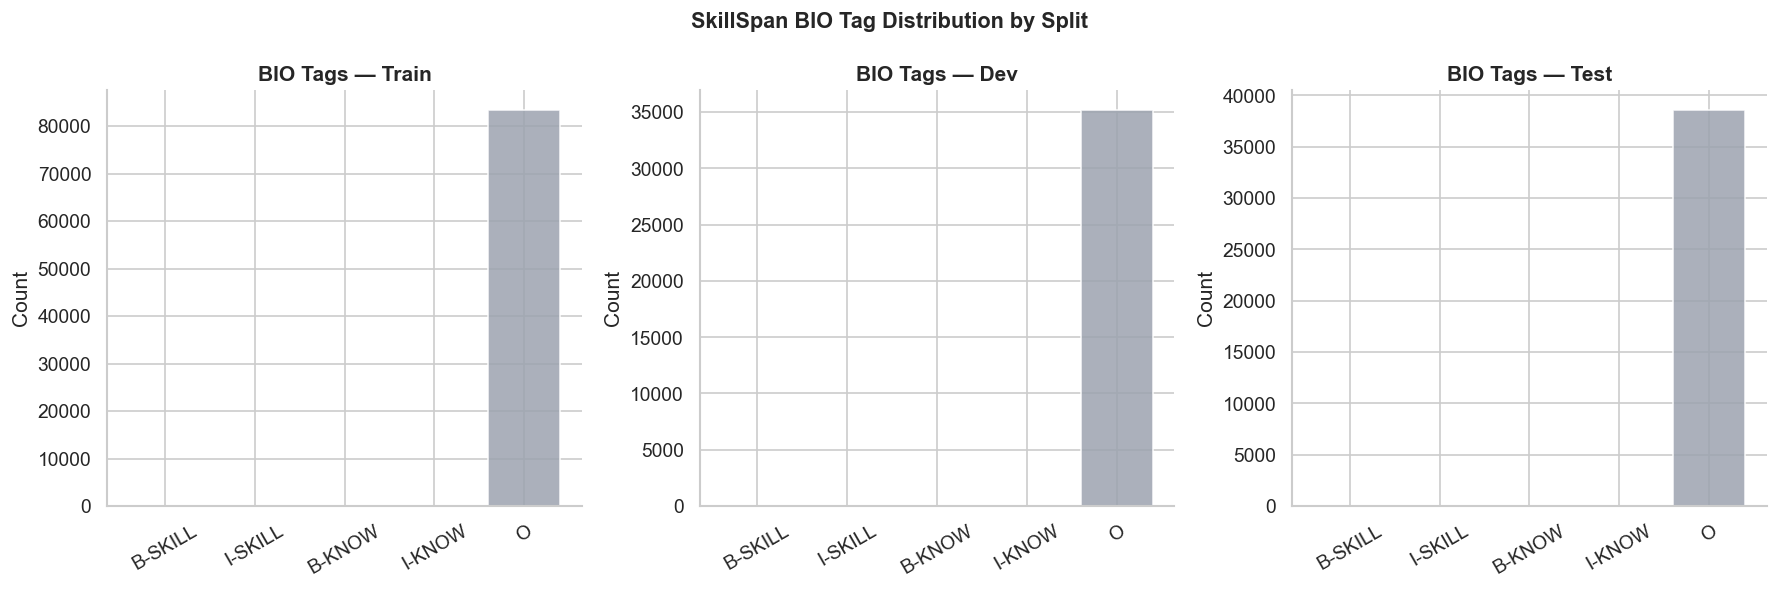

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, stats in zip(axes, [train_stats, dev_stats, test_stats]):
    tag_names = ["B-SKILL","I-SKILL","B-KNOW","I-KNOW","O"]
    tag_vals  = [stats["skill_B_tags"], stats["skill_I_tags"],
                 stats["know_B_tags"],  stats["know_I_tags"], stats["O_tags"]]
    colors    = [PALETTE_MAIN,"#60A5FA",PALETTE_ACCENT,"#FCD34D","#9CA3AF"]
    ax.bar(tag_names, tag_vals, color=colors, alpha=0.85)
    ax.set_title(f"BIO Tags — {stats['split'].capitalize()}", fontweight="bold")
    ax.set_ylabel("Count"); ax.tick_params(axis="x", rotation=30)

plt.suptitle("SkillSpan BIO Tag Distribution by Split", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()


## 9. Temporal Skill Trend Analysis

> **📌 Data Context:** Dataset covers 28 days (Mar 24 – Apr 20, 2024) → only 2 calendar months.  
> We use **weekly granularity** to maximize time points (4–5 weeks available).  
> Trend metrics combine temporal signals with **cross-sectional features** (volume, salary, recency).

**Metrics computed per skill:**

| Metric | Method |
|--------|--------|
| Weekly Demand | Distinct job postings per skill per week |
| Linear Slope | OLS slope on EWM-smoothed weekly demand |
| Growth Rate | (last week − first week) / first week |
| Momentum Score | EWM of weekly demand differences |
| Trend Score | Composite: temporal + volume + salary components |


In [23]:
# ── Build skill_ts: skills joined with weekly timestamps ──────────────────────
skill_ts = (
    job_skills_raw
    .merge(
        postings[["job_id","listed_time","listed_week","listed_ym","normalized_salary"]],
        on="job_id", how="inner"
    )
    .merge(skills_raw, on="skill_abr", how="left")
    .dropna(subset=["listed_time","skill_name"])
)

print(f"skill_ts shape     : {skill_ts.shape}")
print(f"Date range         : {skill_ts['listed_time'].min().date()} → {skill_ts['listed_time'].max().date()}")
print(f"Unique weeks       : {skill_ts['listed_week'].nunique()}")
print(f"Unique months      : {skill_ts['listed_ym'].nunique()}")
print(f"Unique skills      : {skill_ts['skill_name'].nunique()}")


skill_ts shape     : (205778, 7)
Date range         : 2024-03-24 → 2024-04-20
Unique weeks       : 4
Unique months      : 2
Unique skills      : 35


In [24]:
# ── Weekly demand per skill ────────────────────────────────────────────────────
weekly_demand = (
    skill_ts
    .groupby(["skill_name","listed_week"])["job_id"]
    .nunique().reset_index()
    .rename(columns={"job_id":"demand_count"})
    .sort_values(["skill_name","listed_week"])
)

# ── Monthly demand (for compatibility with downstream cells) ──────────────────
monthly_demand = (
    skill_ts
    .groupby(["skill_name","listed_ym"])["job_id"]
    .nunique().reset_index()
    .rename(columns={"job_id":"demand_count"})
    .sort_values(["skill_name","listed_ym"])
)

print(f"Weekly demand shape  : {weekly_demand.shape}")
print(f"Monthly demand shape : {monthly_demand.shape}")
print(f"\nWeeks per skill:")
print(weekly_demand.groupby("skill_name")["listed_week"].nunique().sort_values(ascending=False).to_string())


Weekly demand shape  : (107, 3)
Monthly demand shape : (37, 3)

Weeks per skill:
skill_name
Manufacturing             4
Management                4
Purchasing                3
Marketing                 3
Other                     3
Product Management        3
Production                3
Project Management        3
Public Relations          3
Accounting/Auditing       3
Research                  3
Sales                     3
Science                   3
Strategy/Planning         3
Supply Chain              3
Training                  3
Quality Assurance         3
Legal                     3
Administrative            3
Design                    3
Advertising               3
Analyst                   3
Art/Creative              3
Business Development      3
Consulting                3
Customer Service          3
Distribution              3
Information Technology    3
Education                 3
Engineering               3
Finance                   3
General Business          3
Health Care 

In [25]:
def compute_skill_trends_robust(
    weekly_df:   pd.DataFrame,
    skill_ts_df: pd.DataFrame,
    postings_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Compute skill trend metrics robust to short time windows.
    Cross-sectional aggregates diambil langsung dari postings_df via job_id.
    """

    # ── Cek kolom yang tersedia di skill_ts_df ────────────────────────────────
    # skill_ts mungkin sudah punya normalized_salary (dari merge sebelumnya),
    # atau tidak — handle kedua kasus
    merge_cols = ["job_id"]
    for col in ["normalized_salary", "remote_allowed"]:
        if col not in skill_ts_df.columns:
            merge_cols.append(col)   # perlu di-merge dari postings_df

    if len(merge_cols) > 1:
        # Ada kolom yang belum ada → merge dari postings_df
        extra_cols = [c for c in merge_cols if c != "job_id"]
        available  = [c for c in extra_cols if c in postings_df.columns]
        base_df    = skill_ts_df.merge(
            postings_df[["job_id"] + available].drop_duplicates("job_id"),
            on="job_id", how="left"
        )
    else:
        base_df = skill_ts_df.copy()

    # ── Pastikan kolom yang dibutuhkan ada (isi NaN jika tidak) ───────────────
    for col in ["normalized_salary", "remote_allowed", "listed_time"]:
        if col not in base_df.columns:
            base_df[col] = np.nan

    # ── Cross-sectional aggregates per skill ──────────────────────────────────
    # listed_time: gunakan dari base_df (skill_ts sudah punya ini)
    agg_dict = {
        "job_id":             ("job_id",             "nunique"),
        "avg_salary":         ("normalized_salary",  "mean"),
        "median_salary":      ("normalized_salary",  "median"),
        "remote_rate":        ("remote_allowed",     "mean"),
        "first_seen":         ("listed_time",        "min"),
        "last_seen":          ("listed_time",        "max"),
    }
    # Hanya agg kolom yang benar-benar ada
    safe_agg = {
        out_col: (src_col, func)
        for out_col, (src_col, func) in agg_dict.items()
        if src_col in base_df.columns
    }

    xsec = base_df.groupby("skill_name").agg(**safe_agg).reset_index()
    xsec.rename(columns={"job_id": "total_jobs"}, inplace=True)

    # active_days: hanya jika first_seen & last_seen tersedia
    if "first_seen" in xsec.columns and "last_seen" in xsec.columns:
        xsec["active_days"] = (
            (xsec["last_seen"] - xsec["first_seen"]).dt.total_seconds() / 86_400
        ).clip(lower=0)
    else:
        xsec["active_days"] = 0.0

    # Pastikan kolom opsional ada walau NaN
    for col in ["median_salary", "remote_rate", "total_jobs", "active_days"]:
        if col not in xsec.columns:
            xsec[col] = np.nan

    # ── Compute per-skill trend metrics ───────────────────────────────────────
    results = []
    for skill, grp in weekly_df.groupby("skill_name"):
        grp = grp.sort_values("listed_week").copy()
        n   = len(grp)

        xs_row        = xsec[xsec["skill_name"] == skill]
        total_jobs    = float(xs_row["total_jobs"].iloc[0])    if len(xs_row) else 0.0
        median_salary = float(xs_row["median_salary"].iloc[0]) if len(xs_row) and xs_row["median_salary"].notna().any() else 0.0
        remote_rate   = float(xs_row["remote_rate"].iloc[0])   if len(xs_row) and xs_row["remote_rate"].notna().any()   else 0.0
        active_days   = float(xs_row["active_days"].iloc[0])   if len(xs_row) else 0.0

        # EWM-smoothed demand
        grp["demand_smooth"] = grp["demand_count"].ewm(span=2, adjust=False).mean()
        recent = float(grp["demand_smooth"].iloc[-1])

        if n >= 2:
            x           = np.arange(n, dtype=float)
            y           = grp["demand_smooth"].values
            slope       = float(np.polyfit(x, y, 1)[0])
            past        = float(grp["demand_smooth"].iloc[0]) + 1e-6
            growth_rate = (recent - past) / past
            diff_s      = grp["demand_smooth"].diff().dropna()
            momentum    = float(diff_s.ewm(span=2, adjust=False).mean().iloc[-1]) if len(diff_s) else 0.0
            acceleration= float(diff_s.diff().mean()) if len(diff_s) >= 2 else 0.0
        else:
            slope = growth_rate = momentum = acceleration = 0.0

        sal_factor   = np.log1p(median_salary / 1_000) if median_salary > 0 else 0.0
        vol_factor   = np.log1p(total_jobs)
        momentum_dir = np.sign(momentum) if momentum != 0 else 1.0
        trend_score  = (
            growth_rate * np.log1p(recent) * momentum_dir
            + 0.3 * vol_factor
            + 0.1 * sal_factor
        )

        results.append({
            "skill_name":        skill,
            "recent_demand":     round(recent, 2),
            "total_jobs":        int(total_jobs),
            "growth_rate":       round(growth_rate, 4),
            "weekly_slope":      round(slope, 4),
            "momentum_score":    round(momentum, 4),
            "acceleration":      round(acceleration, 4),
            "trend_score":       round(trend_score, 4),
            "median_salary":     round(median_salary, 0) if median_salary > 0 else None,
            "remote_rate":       round(remote_rate, 4),
            "active_days":       round(active_days, 1),
            "observation_weeks": n,
        })

    return (
        pd.DataFrame(results)
        .sort_values("trend_score", ascending=False)
        .reset_index(drop=True)
    )


# ── Run ───────────────────────────────────────────────────────────────────────
skill_trends = compute_skill_trends_robust(weekly_demand, skill_ts, postings)

print(f"Skill trends computed for {len(skill_trends)} skills")
print(f"   Observation weeks: {skill_trends['observation_weeks'].min()} – {skill_trends['observation_weeks'].max()}")
display(skill_trends)

Skill trends computed for 35 skills
   Observation weeks: 3 – 4


,skill_name,recent_demand,total_jobs,growth_rate,weekly_slope,momentum_score,acceleration,trend_score,median_salary,remote_rate,active_days,observation_weeks
0,Management,"10,626.26",20385,"10,625.25","3,346.82","5,583.90","3,091.07","98,511.95","59,280.00",0.04,26.10,4
1,Manufacturing,"9,232.85",17728,"9,231.84","2,906.24","4,850.02","2,677.81","84,295.89","55,000.00",0.03,26.10,4
2,Distribution,226.67,409,9.30,102.33,124.44,132.67,52.71,"60,320.00",0.07,14.20,3
3,Engineering,"6,747.89",12530,5.46,"2,851.44","3,521.70","4,021.56",51.43,"120,000.00",0.17,14.20,3
4,Information Technology,"13,440.67",25256,4.98,"5,597.33","6,887.78","7,742.67",50.90,"112,500.00",0.18,14.20,3
5,Customer Service,"2,204.33",4167,6.00,944.67,"1,130.22","1,113.33",49.07,"50,000.00",0.12,14.20,3
6,Consulting,"1,253.11",2241,6.12,538.56,685.63,882.44,46.45,"114,400.00",0.28,14.20,3
7,Science,444.11,782,7.07,194.56,248.30,322.44,45.60,"91,242.00",0.13,14.20,3
8,Project Management,"2,045.89",3825,5.45,864.44,"1,059.04","1,167.56",44.53,"114,400.00",0.15,14.20,3
9,Supply Chain,636.67,1167,6.23,274.33,339.11,388.67,42.83,"89,200.00",0.09,14.20,3


### 9.1 Weekly Demand Trend — Top 8 Skills

In [26]:
top_trend_skills = skill_trends.head(8)["skill_name"].tolist()
trend_plot = weekly_demand[weekly_demand["skill_name"].isin(top_trend_skills)].copy()
trend_plot["week_str"] = trend_plot["listed_week"].astype(str)

fig = px.line(trend_plot, x="week_str", y="demand_count", color="skill_name",
              title="Weekly Job Demand — Top 8 Trending Skills",
              labels={"week_str":"Week","demand_count":"Job Postings","skill_name":"Skill"},
              markers=True)
fig.update_layout(plot_bgcolor="white", height=480,
                  legend=dict(orientation="h", yanchor="bottom", y=1.02))
fig.show()


### 9.2 Emerging vs Declining Skills

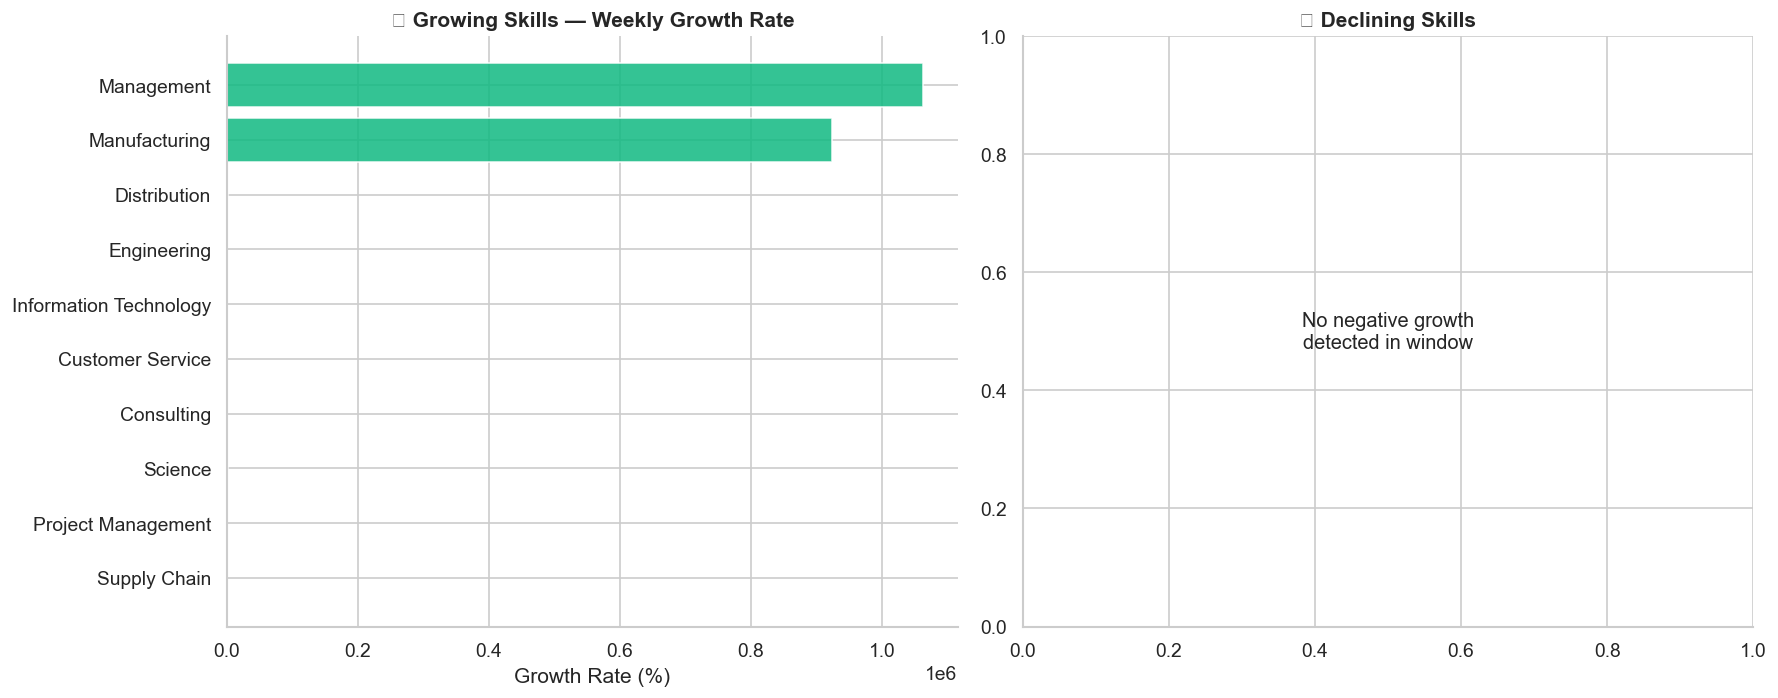


Growing  : 10 skills | Declining: 0 skills


In [ ]:
# Skills with positive vs negative growth rate
emerging_skills  = skill_trends[skill_trends["growth_rate"] > 0].head(10)
declining_skills = skill_trends[skill_trends["growth_rate"] < 0].tail(10).sort_values("growth_rate")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

if len(emerging_skills) > 0:
    axes[0].barh(emerging_skills["skill_name"], emerging_skills["growth_rate"]*100,
                 color=PALETTE_POS, alpha=0.85)
    axes[0].set_title("🚀 Growing Skills — Weekly Growth Rate", fontweight="bold")
    axes[0].set_xlabel("Growth Rate (%)")
    axes[0].invert_yaxis()
else:
    axes[0].text(0.5, 0.5, "No positive growth\ndetected in window",
                 ha="center", va="center", transform=axes[0].transAxes, fontsize=12)
    axes[0].set_title("🚀 Growing Skills", fontweight="bold")

if len(declining_skills) > 0:
    axes[1].barh(declining_skills["skill_name"], declining_skills["growth_rate"]*100,
                 color=PALETTE_NEG, alpha=0.85)
    axes[1].set_title("📉 Declining Skills — Weekly Growth Rate", fontweight="bold")
    axes[1].set_xlabel("Growth Rate (%)")
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, "No negative growth\ndetected in window",
                 ha="center", va="center", transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title("📉 Declining Skills", fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "emerging_declining_skills.png", bbox_inches="tight")
plt.show()

print(f"\nGrowing  : {len(emerging_skills)} skills | Declining: {len(declining_skills)} skills")

### 9.3 Skill Momentum Map

In [28]:
# Ensure recent_demand > 0 for bubble size (plotly requires positive values)
plot_df = skill_trends.copy()
plot_df["bubble_size"] = (plot_df["recent_demand"] - plot_df["recent_demand"].min() + 1)

fig = px.scatter(
    plot_df, x="growth_rate", y="momentum_score",
    size="bubble_size", color="trend_score",
    hover_name="skill_name",
    color_continuous_scale="RdYlGn",
    title="Skill Momentum Map: Growth Rate vs Momentum Score",
    labels={"growth_rate":"Weekly Growth Rate","momentum_score":"Momentum Score",
            "trend_score":"Trend Score"},
    size_max=45
)
fig.add_hline(y=0, line_dash="dot", line_color="gray", annotation_text="Zero momentum")
fig.add_vline(x=0, line_dash="dot", line_color="gray", annotation_text="Zero growth")
fig.update_layout(plot_bgcolor="white", height=520)
fig.show()

print("\nQuadrant Interpretation:")
print("   Q1 (top-right) : High growth + positive momentum → ACCELERATING")
print("   Q2 (top-left)  : Negative growth but recovering  → REBOUNDING")
print("   Q3 (bot-left)  : Negative growth + declining     → FADING")
print("   Q4 (bot-right) : High growth but slowing         → MATURING")



Quadrant Interpretation:
   Q1 (top-right) : High growth + positive momentum → ACCELERATING
   Q2 (top-left)  : Negative growth but recovering  → REBOUNDING
   Q3 (bot-left)  : Negative growth + declining     → FADING
   Q4 (bot-right) : High growth but slowing         → MATURING


## 10. Industry Workforce Intelligence

Skill demand, salary trends, and technology adoption at the **industry level**.

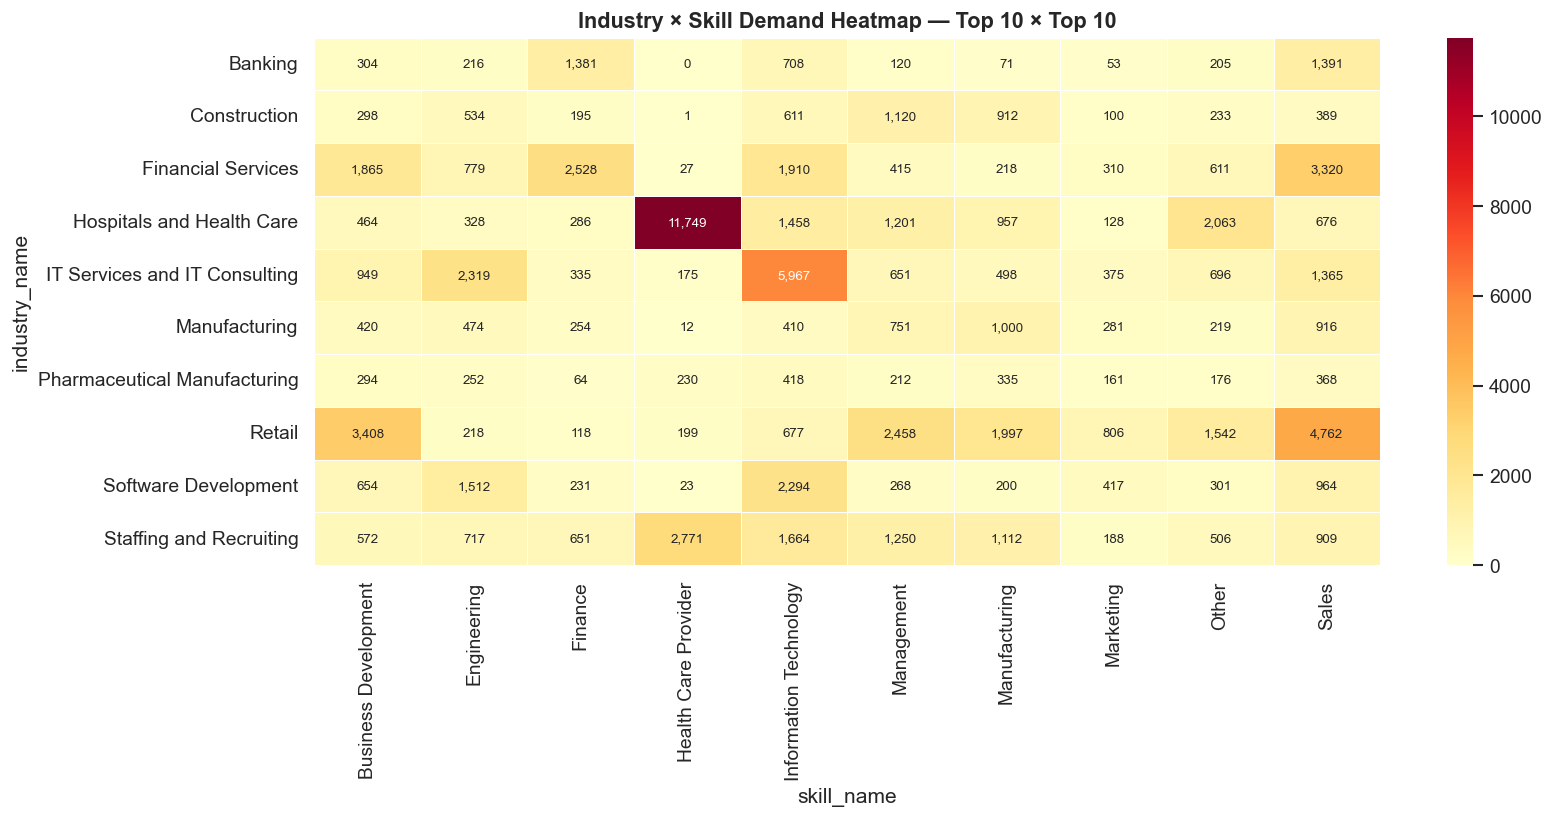

In [29]:
# ── Industry × skill affinity ─────────────────────────────────────────────────
industry_skill = (
    job_industries_raw
    .merge(industries_raw,  on="industry_id", how="left")
    .merge(job_skills_raw,  on="job_id",      how="inner")
    .merge(skills_raw,      on="skill_abr",   how="left")
    .groupby(["industry_name","skill_name"])["job_id"]
    .nunique().reset_index()
    .rename(columns={"job_id":"job_count"})
)

top_ind = industry_skill.groupby("industry_name")["job_count"].sum().nlargest(10).index
top_skl = industry_skill.groupby("skill_name")["job_count"].sum().nlargest(10).index

pivot_heatmap = (
    industry_skill[
        industry_skill["industry_name"].isin(top_ind) &
        industry_skill["skill_name"].isin(top_skl)
    ]
    .pivot_table(index="industry_name", columns="skill_name",
                 values="job_count", aggfunc="sum", fill_value=0)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot_heatmap, annot=True, fmt=",d", cmap="YlOrRd",
            linewidths=0.3, ax=ax, annot_kws={"size": 8})
ax.set_title("Industry × Skill Demand Heatmap — Top 10 × Top 10", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()


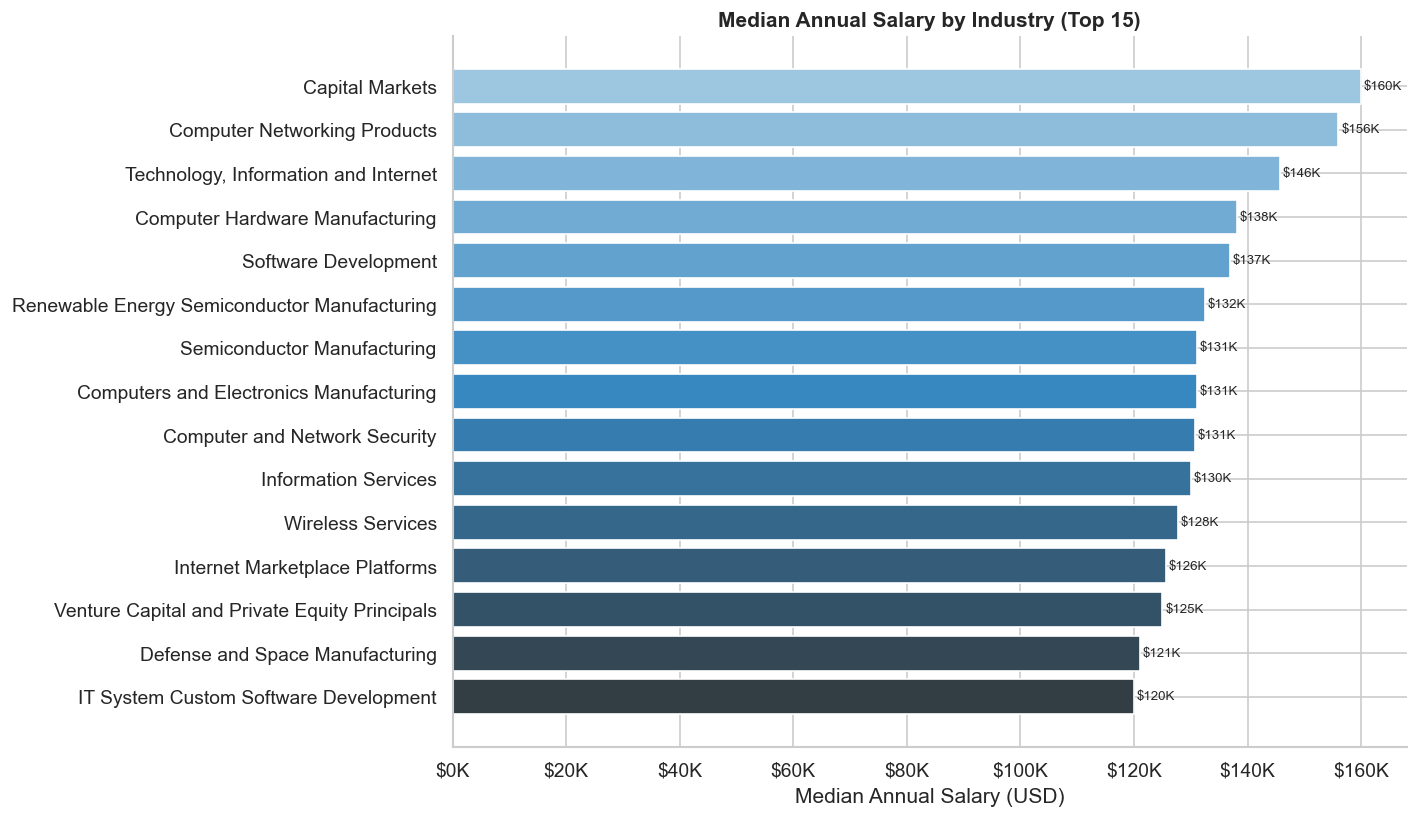

In [30]:
# ── Median salary per industry ────────────────────────────────────────────────
industry_salary = (
    job_industries_raw
    .merge(industries_raw, on="industry_id", how="left")
    .merge(postings[["job_id","normalized_salary"]], on="job_id", how="inner")
    .dropna(subset=["normalized_salary"])
    .query("normalized_salary > 10_000 and normalized_salary < 1_000_000")
)

ind_sal = (
    industry_salary.groupby("industry_name")["normalized_salary"]
    .agg(["median","count"]).reset_index()
    .query("count >= 50").sort_values("median", ascending=False).head(15)
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(ind_sal["industry_name"], ind_sal["median"],
               color=sns.color_palette("Blues_d", len(ind_sal)))
ax.set_title("Median Annual Salary by Industry (Top 15)", fontweight="bold")
ax.set_xlabel("Median Annual Salary (USD)"); ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1000:.0f}K"))
for bar in bars:
    ax.text(bar.get_width()+500, bar.get_y()+bar.get_height()/2,
            f"${bar.get_width()/1000:.0f}K", va="center", fontsize=8)
plt.tight_layout()
plt.show()


## 11. Feature Engineering

Rich feature set: **TF-IDF · Skill signals · Trend scores · Salary features**.

In [31]:
# ── TF-IDF on job descriptions ────────────────────────────────────────────────
print("Building TF-IDF feature matrix...")
desc_mask   = postings["desc_lowercase"].str.len() > 50
desc_corpus = postings.loc[desc_mask, "desc_lowercase"].tolist()
desc_ids    = postings.loc[desc_mask, "job_id"].tolist()

tfidf_vectorizer = TfidfVectorizer(
    max_features=5_000, min_df=5, max_df=0.85,
    ngram_range=(1, 2), sublinear_tf=True,
)
tfidf_matrix = tfidf_vectorizer.fit_transform(desc_corpus)

print(f"TF-IDF matrix: {tfidf_matrix.shape}")

feature_names = tfidf_vectorizer.get_feature_names_out()
mean_tfidf    = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top20_idx     = mean_tfidf.argsort()[::-1][:20]
print("\nTop 20 TF-IDF Terms:")
for i, idx in enumerate(top20_idx):
    print(f"  {i+1:>2}. {feature_names[idx]:<30} {mean_tfidf[idx]:.4f}")


Building TF-IDF feature matrix...
TF-IDF matrix: (123773, 5000)

Top 20 TF-IDF Terms:
   1. our                            0.0295
   2. you                            0.0279
   3. we                             0.0278
   4. work                           0.0263
   5. are                            0.0258
   6. be                             0.0255
   7. an                             0.0247
   8. will                           0.0242
   9. all                            0.0232
  10. team                           0.0230
  11. that                           0.0228
  12. this                           0.0224
  13. at                             0.0217
  14. skills                         0.0215
  15. by                             0.0212
  16. your                           0.0207
  17. of the                         0.0204
  18. job                            0.0204
  19. other                          0.0202
  20. in the                         0.0198


In [32]:
# ── SVD dimensionality reduction ──────────────────────────────────────────────
svd = TruncatedSVD(n_components=50, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)
print(f"SVD-reduced TF-IDF : {tfidf_reduced.shape}")
print(f"Explained variance  : {svd.explained_variance_ratio_.sum():.3f}")

# ── Skill frequency features per posting ──────────────────────────────────────
skill_freq_per_job = (
    job_skills_raw.groupby("job_id")["skill_abr"]
    .agg(["count","nunique"]).reset_index()
    .rename(columns={"count":"skill_tag_count","nunique":"unique_skill_count"})
)

# ── Merge trend scores onto each job ─────────────────────────────────────────
job_skill_trend = (
    job_skills_raw
    .merge(skills_raw, on="skill_abr", how="left")
    .merge(skill_trends[["skill_name","trend_score","growth_rate","momentum_score"]],
           on="skill_name", how="left")
    .groupby("job_id")
    .agg(avg_skill_trend=("trend_score","mean"),
         max_skill_trend=("trend_score","max"),
         avg_growth_rate=("growth_rate","mean"),
         avg_momentum   =("momentum_score","mean"))
    .reset_index()
)

# ── Build feature DataFrame ───────────────────────────────────────────────────
feature_df = postings[[
    "job_id","title","normalized_salary","formatted_experience_level",
    "remote_allowed","listed_week","listed_ym",
    "posting_duration_days","work_type"
]].copy()
feature_df["listed_week"] = feature_df["listed_week"].astype(str)
feature_df["listed_ym"]   = feature_df["listed_ym"].astype(str)

feature_df = feature_df.merge(skill_freq_per_job, on="job_id", how="left")
feature_df = feature_df.merge(job_skill_trend,    on="job_id", how="left")

feature_df["salary_pctile_exp"] = feature_df.groupby("formatted_experience_level")["normalized_salary"]     .transform(lambda x: x.rank(pct=True))

le  = LabelEncoder()
feature_df["exp_level_encoded"] = le.fit_transform(
    feature_df["formatted_experience_level"].fillna("Not Specified")
)

scaler    = MinMaxScaler()
num_cols  = ["normalized_salary","unique_skill_count","avg_skill_trend",
             "avg_growth_rate","avg_momentum","salary_pctile_exp"]
feature_df[[f"{c}_scaled" for c in num_cols]] = scaler.fit_transform(
    feature_df[num_cols].fillna(0)
)

print(f"\nFeature DataFrame shape: {feature_df.shape}")
display(feature_df.head(3))


SVD-reduced TF-IDF : (123773, 50)
Explained variance  : 0.170

Feature DataFrame shape: (123849, 23)


,job_id,title,normalized_salary,formatted_experience_level,remote_allowed,listed_week,listed_ym,posting_duration_days,work_type,skill_tag_count,unique_skill_count,avg_skill_trend,max_skill_trend,avg_growth_rate,avg_momentum,salary_pctile_exp,exp_level_encoded,normalized_salary_scaled,unique_skill_count_scaled,avg_skill_trend_scaled,avg_growth_rate_scaled,avg_momentum_scaled,salary_pctile_exp_scaled
0,921716,Marketing Coordinator,"38,480.00",Not Specified,0,2024-04-15/2024-04-21,2024-04,30.00,FULL_TIME,2.00,2.00,37.14,37.48,3.95,"3,404.37",0.10,6,0.01,0.67,0.00,0.00,0.49,0.10
1,1829192,Mental Health Therapist/Counselor,"83,200.00",Not Specified,0,2024-04-08/2024-04-14,2024-04,30.00,FULL_TIME,1.00,1.00,22.93,22.93,2.17,"3,453.26",0.55,6,0.02,0.33,0.00,0.00,0.50,0.55
2,10998357,Assitant Restaurant Manager,"55,000.00",Not Specified,0,2024-04-15/2024-04-21,2024-04,30.00,FULL_TIME,2.00,2.00,"91,403.92","98,511.95","9,928.55","5,216.96",0.29,6,0.01,0.67,0.93,0.93,0.76,0.29


## 12. Dataset Preparation

Generating 7 production-ready output datasets for downstream modeling.

In [33]:
OUTPUT_DIR    = Path("final_datasets")
OUTPUT_DIR.mkdir(exist_ok=True)
print("Generating output datasets...")
print("-" * 55)

# ── 1. processed_job_postings.csv ─────────────────────────────────────────────
# Keep only essential columns to minimise file size.
# Columns excluded: desc_lowercase, desc_tokens, desc_token_count,
#   skills_desc_normalized, normalized_salary, remote_allowed,
#   original_listed_time, expiry, closed_time, posting_duration_days,
#   work_type, company_id
KEEP_COLS = [
    "job_id",
    "title",
    "description",
    "desc_normalized",
    "skills_desc",
    "location",
    "listed_time",
    "listed_month",
    "listed_year",
    "company_name",
    "formatted_experience_level",
    "formatted_work_type",
]
existing_cols = [c for c in KEEP_COLS if c in postings.columns]
processed_job_postings = postings[existing_cols].copy()

# Convert datetime to ISO string (avoids timezone-aware serialisation issues)
if "listed_time" in processed_job_postings.columns:
    processed_job_postings["listed_time"] = (
        processed_job_postings["listed_time"].astype(str)
    )

processed_job_postings.to_csv(
    OUTPUT_DIR / "processed_job_postings.csv",
    index=False,
)

file_mb = (OUTPUT_DIR / "processed_job_postings.csv").stat().st_size / 1_048_576
print(f"  ✅ processed_job_postings.csv    : {len(processed_job_postings):,} rows  |  {file_mb:.1f} MB")
print(f"     Columns kept  : {list(processed_job_postings.columns)}")

# ── 2. master_skills.csv ──────────────────────────────────────────────────────
master_skills = (
    skills_raw
    .merge(skill_trends, on="skill_name", how="left")
    .merge(skill_counts.rename(columns={"skill":"skill_name"}), on="skill_name", how="left")
)
master_skills.to_csv(OUTPUT_DIR / "master_skills.csv", index=False)
print(f"  ✅ master_skills.csv             : {len(master_skills):,} rows")

# ── 3. job_skill_mapping.csv ──────────────────────────────────────────────────
job_skill_mapping = (
    job_skills_raw
    .merge(skills_raw, on="skill_abr", how="left")
    .merge(postings[["job_id","title","listed_ym"]], on="job_id", how="left")
)
job_skill_mapping["listed_ym"] = job_skill_mapping["listed_ym"].astype(str)
job_skill_mapping.to_csv(OUTPUT_DIR / "job_skill_mapping.csv", index=False)
print(f"  ✅ job_skill_mapping.csv         : {len(job_skill_mapping):,} rows")

# ── 4. skill_trend_timeseries.csv ─────────────────────────────────────────────
skill_ts_export = weekly_demand.copy()
skill_ts_export["listed_week"] = skill_ts_export["listed_week"].astype(str)
skill_ts_export = skill_ts_export.merge(
    skill_trends[["skill_name","growth_rate","momentum_score","trend_score","weekly_slope"]],
    on="skill_name", how="left"
)
skill_ts_export.to_csv(OUTPUT_DIR / "skill_trend_timeseries.csv", index=False)
print(f"  ✅ skill_trend_timeseries.csv    : {len(skill_ts_export):,} rows")

# ── 5. industry_skill_trend.csv ───────────────────────────────────────────────
industry_skill.to_csv(OUTPUT_DIR / "industry_skill_trend.csv", index=False)
print(f"  ✅ industry_skill_trend.csv      : {len(industry_skill):,} rows")

# ── 6. emerging_skills.csv ────────────────────────────────────────────────────
emerging_skills_df = (
    skill_trends[skill_trends["trend_score"] > 0]
    .merge(skills_raw, on="skill_name", how="left")
)
emerging_skills_df.to_csv(OUTPUT_DIR / "emerging_skills.csv", index=False)
print(f"  ✅ emerging_skills.csv           : {len(emerging_skills_df):,} rows")

# ── 7. career_transition_dataset.csv ──────────────────────────────────────────
job_skill_agg = (
    job_skills_raw
    .groupby("job_id")["skill_abr"]
    .apply(frozenset).reset_index()
    .rename(columns={"skill_abr":"skill_set"})
    .merge(postings[["job_id","title","formatted_experience_level","normalized_salary"]],
           on="job_id", how="left")
    .dropna(subset=["title"])
)

sample_size = min(3_000, len(job_skill_agg))
sample_jobs = job_skill_agg.sample(n=sample_size, random_state=42).reset_index(drop=True)

career_transitions = []
MAX_PAIRS = 30_000
for i in range(len(sample_jobs)):
    if len(career_transitions) >= MAX_PAIRS:
        break
    row_a = sample_jobs.iloc[i]
    for j in range(i + 1, len(sample_jobs)):
        overlap = len(row_a["skill_set"] & sample_jobs.iloc[j]["skill_set"])
        if overlap >= 2:
            row_b = sample_jobs.iloc[j]
            career_transitions.append({
                "job_id_a":    row_a["job_id"],   "title_a":    row_a["title"],
                "exp_level_a": row_a["formatted_experience_level"],
                "salary_a":    row_a["normalized_salary"],
                "job_id_b":    row_b["job_id"],   "title_b":    row_b["title"],
                "exp_level_b": row_b["formatted_experience_level"],
                "salary_b":    row_b["normalized_salary"],
                "shared_skills": overlap,
                "similarity":  overlap / max(len(row_a["skill_set"] | row_b["skill_set"]), 1),
            })
            if len(career_transitions) >= MAX_PAIRS:
                break

career_df = pd.DataFrame(career_transitions)
career_df.to_csv(OUTPUT_DIR / "career_transition_dataset.csv", index=False)
print(f"  ✅ career_transition_dataset.csv : {len(career_df):,} rows")


Generating output datasets...
-------------------------------------------------------
  ✅ processed_job_postings.csv    : 123,849 rows  |  905.5 MB
     Columns kept  : ['job_id', 'title', 'description', 'desc_normalized', 'skills_desc', 'location', 'listed_time', 'listed_month', 'listed_year', 'company_name', 'formatted_experience_level', 'formatted_work_type']
  ✅ master_skills.csv             : 35 rows
  ✅ job_skill_mapping.csv         : 213,768 rows
  ✅ skill_trend_timeseries.csv    : 107 rows
  ✅ industry_skill_trend.csv      : 7,128 rows
  ✅ emerging_skills.csv           : 35 rows
  ✅ career_transition_dataset.csv : 30,000 rows


## 13. Data Quality Check

Systematic quality audit across the **5-Dimension DQ Framework**: Completeness · Uniqueness · Validity · Consistency · Temporal.

In [35]:
def run_dq_check(df: pd.DataFrame, name: str, key_col=None) -> pd.DataFrame:
    results = []

    # 1. Completeness
    avg_complete = (1 - df.isnull().mean()).mean() * 100
    results.append({"dimension":"Completeness", "metric":"Avg non-null (%)",
                    "value": round(avg_complete,2),
                    "status":"✅ PASS" if avg_complete >= 70 else "⚠️  WARN"})

    # 2. Uniqueness
    if key_col and key_col in df.columns:
        dup_pct = df.duplicated(subset=key_col).mean() * 100
        results.append({"dimension":"Uniqueness",
                        "metric": f"Duplicate key rate (%) [{key_col}]",
                        "value": round(dup_pct,2),
                        "status":"✅ PASS" if dup_pct < 1 else "⚠️  WARN"})

    # 3. Validity
    inf_total = sum(
        np.isinf(df[c]).sum() for c in df.select_dtypes(include=np.number).columns
    )
    results.append({"dimension":"Validity", "metric":"Inf values (total)",
                    "value": inf_total,
                    "status":"✅ PASS" if inf_total == 0 else "⚠️  WARN"})

    # 4. Row count
    results.append({"dimension":"Validity", "metric":"Row count",
                    "value": len(df),
                    "status":"✅ PASS" if len(df) > 0 else "❌ FAIL"})

    return pd.DataFrame(results)

print("DATA QUALITY REPORT")
print("=" * 65)
for fname, key in [
    ("processed_job_postings.csv", "job_id"),
    ("master_skills.csv",          "skill_name"),
    ("skill_trend_timeseries.csv", None),
    ("emerging_skills.csv",        "skill_name"),
    ("career_transition_dataset.csv", None),
]:
    path = OUTPUT_DIR / fname
    if not path.exists():
        print(f"\n  [{fname}] — FILE NOT FOUND, skipping")
        continue
    df_check = pd.read_csv(path)
    dq = run_dq_check(df_check, fname, key_col=key)
    print(f"\n  [{fname}]  ({len(df_check):,} rows)")
    display(dq)


DATA QUALITY REPORT

  [processed_job_postings.csv]  (123,849 rows)


,dimension,metric,value,status
0,Completeness,Avg non-null (%),91.71,✅ PASS
1,Uniqueness,Duplicate key rate (%) [job_id],0.00,✅ PASS
2,Validity,Inf values (total),0.00,✅ PASS
3,Validity,Row count,"123,849.00",✅ PASS



  [master_skills.csv]  (35 rows)


,dimension,metric,value,status
0,Completeness,Avg non-null (%),100.00,✅ PASS
1,Uniqueness,Duplicate key rate (%) [skill_name],0.00,✅ PASS
2,Validity,Inf values (total),0.00,✅ PASS
3,Validity,Row count,35.00,✅ PASS



  [skill_trend_timeseries.csv]  (107 rows)


,dimension,metric,value,status
0,Completeness,Avg non-null (%),100.00,✅ PASS
1,Validity,Inf values (total),0.00,✅ PASS
2,Validity,Row count,107.00,✅ PASS



  [emerging_skills.csv]  (35 rows)


,dimension,metric,value,status
0,Completeness,Avg non-null (%),100.00,✅ PASS
1,Uniqueness,Duplicate key rate (%) [skill_name],0.00,✅ PASS
2,Validity,Inf values (total),0.00,✅ PASS
3,Validity,Row count,35.00,✅ PASS



  [career_transition_dataset.csv]  (30,000 rows)


,dimension,metric,value,status
0,Completeness,Avg non-null (%),85.21,✅ PASS
1,Validity,Inf values (total),0.00,✅ PASS
2,Validity,Row count,"30,000.00",✅ PASS


## 14. Visualization & Explanatory Analysis

Comprehensive visual intelligence across salary trends, skill demand, and trend scoring.

### 14.1 Salary Trend Over Time (Weekly)

In [36]:
sal_trend = (
    postings
    .dropna(subset=["normalized_salary"])
    .query("normalized_salary > 10_000 and normalized_salary < 1_000_000")
    .assign(week_str=postings["listed_week"].astype(str))
    .groupby("week_str")["normalized_salary"]
    .agg(["median","mean","count"])
    .reset_index()
    .query("count >= 50")
)

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=sal_trend["week_str"], y=sal_trend["median"],
    name="Median Salary", line=dict(color="#2563EB", width=2.5)), secondary_y=False)
fig.add_trace(go.Scatter(x=sal_trend["week_str"], y=sal_trend["mean"],
    name="Mean Salary", line=dict(color="#F59E0B", width=2, dash="dot")), secondary_y=False)
fig.add_trace(go.Bar(x=sal_trend["week_str"], y=sal_trend["count"],
    name="Posting Volume", marker_color="rgba(16,185,129,0.25)"), secondary_y=True)
fig.update_layout(title="Weekly Salary Trend vs Posting Volume", plot_bgcolor="white",
                  height=460, legend=dict(orientation="h"))
fig.update_yaxes(title_text="Annual Salary (USD)", secondary_y=False, tickformat="$,.0f")
fig.update_yaxes(title_text="Posting Volume",      secondary_y=True)
fig.show()


### 14.2 Skill Demand Heatmap — Weekly

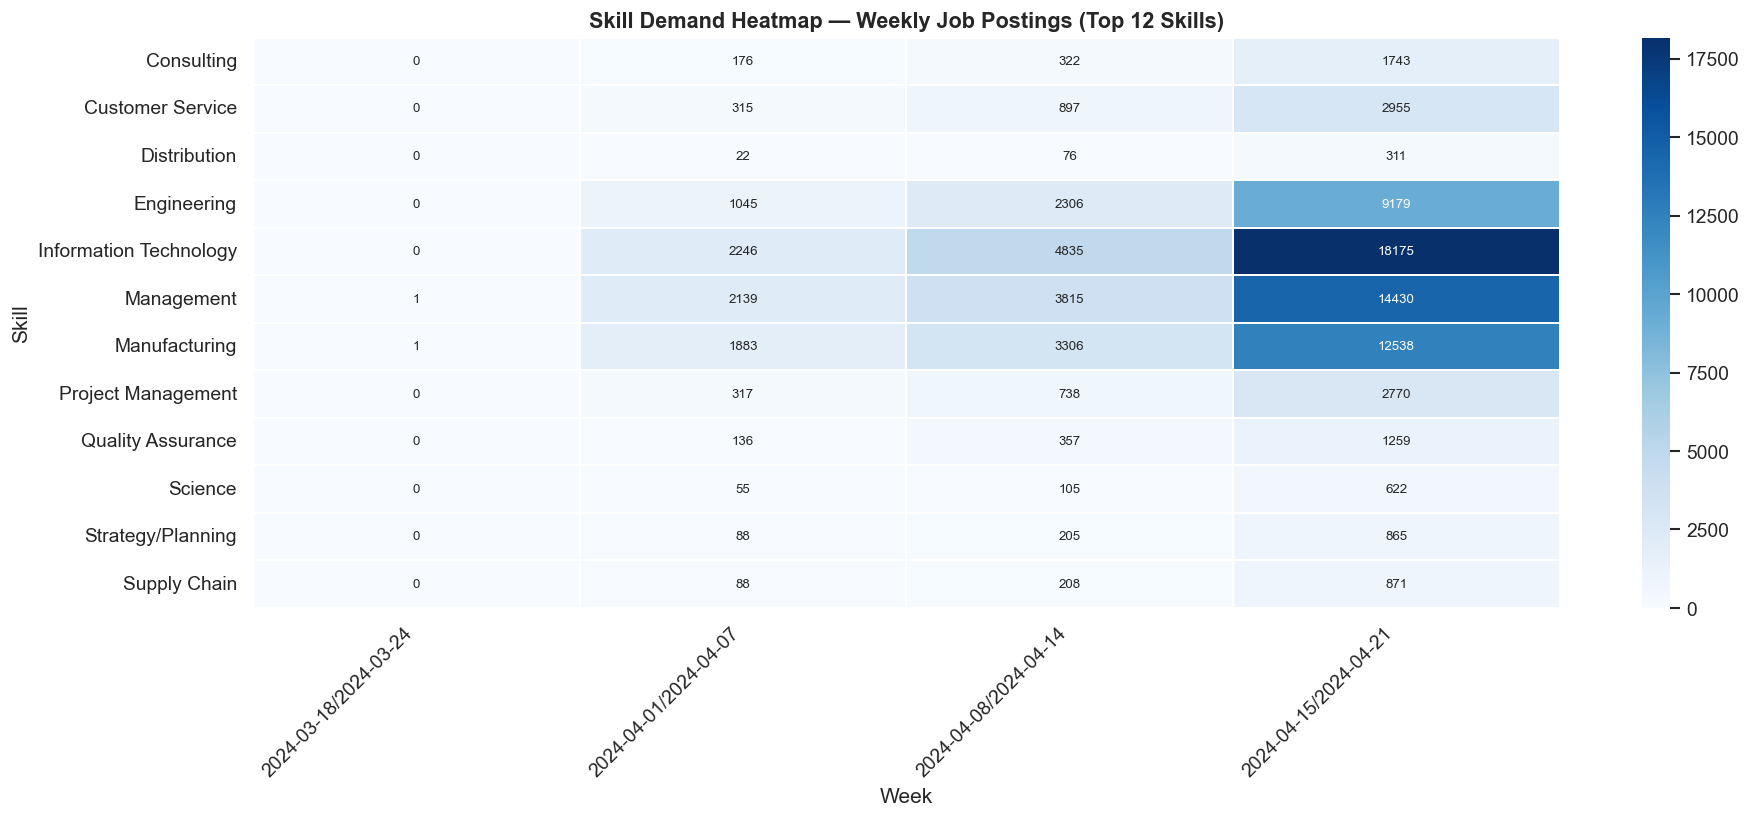


💡 Insight: Keterampilan yang selalu diminati setiap minggunya menandakan kebutuhan perekrutan yang matang dan stabil.


In [37]:
TOP_SKILLS_HEAT = skill_trends.head(12)["skill_name"].tolist()
heat_data = weekly_demand[weekly_demand["skill_name"].isin(TOP_SKILLS_HEAT)].copy()
heat_data["week_str"] = heat_data["listed_week"].astype(str)
heat_pivot = heat_data.pivot_table(
    index="skill_name", columns="week_str",
    values="demand_count", fill_value=0
)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(heat_pivot, cmap="Blues", linewidths=0.2, ax=ax,
            annot=True, fmt=".0f", annot_kws={"size": 8})
ax.set_title("Skill Demand Heatmap — Weekly Job Postings (Top 12 Skills)",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Week"); ax.set_ylabel("Skill")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n💡 Insight: Keterampilan yang selalu diminati setiap minggunya menandakan kebutuhan perekrutan yang matang dan stabil.")

### 14.3 Trend Score & Growth Rate Ranking

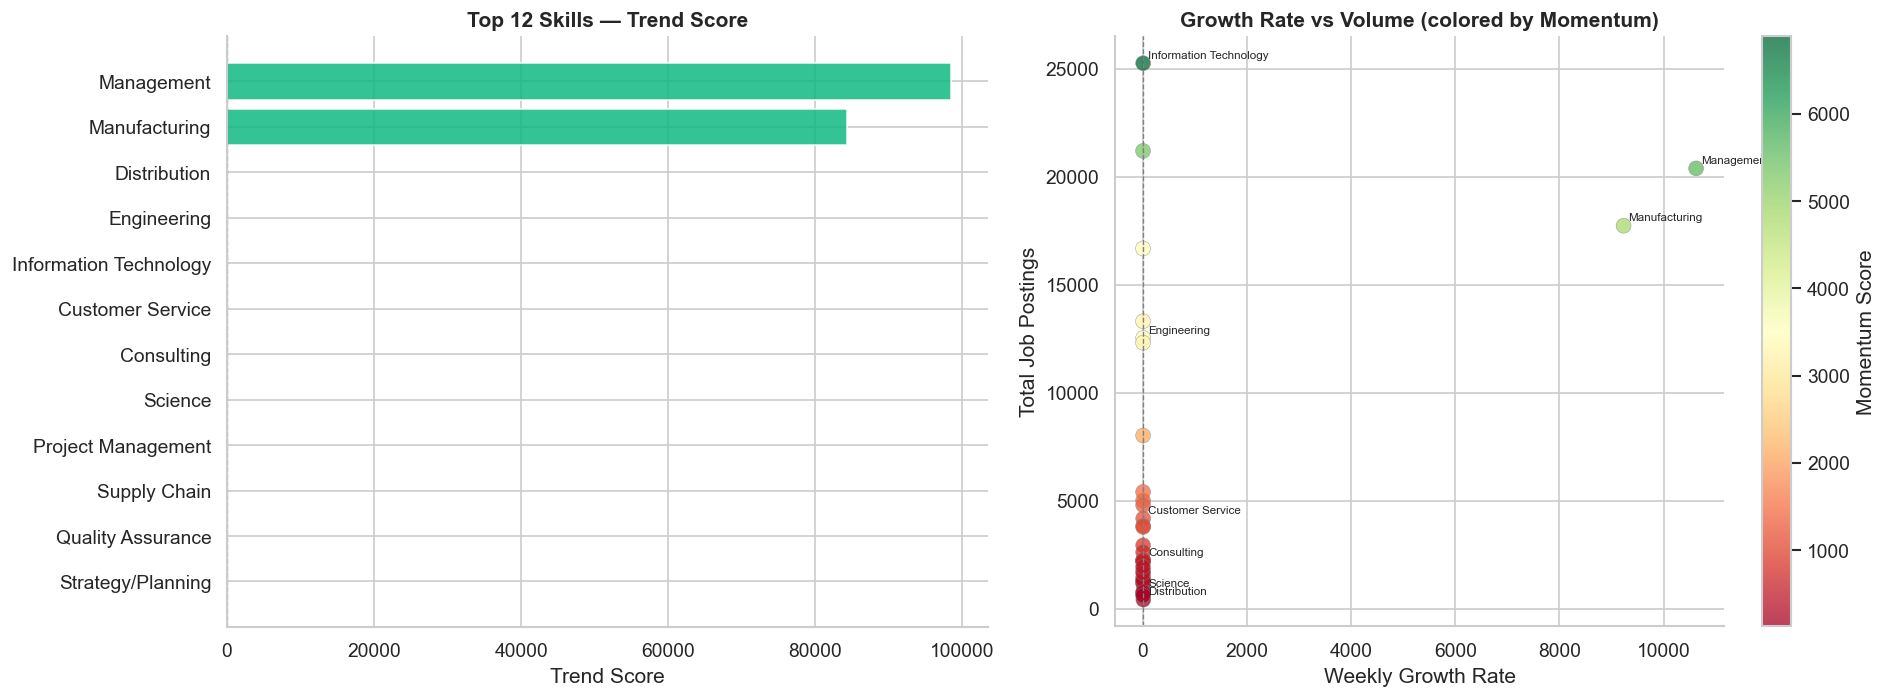

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Trend score bar
top_trend = skill_trends.head(12).copy()
colors_bar = [PALETTE_POS if v >= 0 else PALETTE_NEG for v in top_trend["trend_score"]]
axes[0].barh(top_trend["skill_name"], top_trend["trend_score"],
             color=colors_bar, alpha=0.85)
axes[0].axvline(0, color="gray", lw=0.8, ls="--")
axes[0].set_title("Top 12 Skills — Trend Score", fontweight="bold")
axes[0].set_xlabel("Trend Score")
axes[0].invert_yaxis()

# Growth rate vs total jobs scatter
sc = axes[1].scatter(
    skill_trends["growth_rate"], skill_trends["total_jobs"],
    c=skill_trends["momentum_score"], cmap="RdYlGn",
    s=80, alpha=0.75, edgecolors="gray", linewidths=0.3
)
plt.colorbar(sc, ax=axes[1], label="Momentum Score")
for _, row in skill_trends.head(8).iterrows():
    axes[1].annotate(row["skill_name"],
                     xy=(row["growth_rate"], row["total_jobs"]),
                     fontsize=7, xytext=(3,3), textcoords="offset points")
axes[1].set_xlabel("Weekly Growth Rate")
axes[1].set_ylabel("Total Job Postings")
axes[1].set_title("Growth Rate vs Volume (colored by Momentum)", fontweight="bold")
axes[1].axvline(0, color="gray", ls="--", lw=0.8)

plt.tight_layout()
plt.show()

### 14.4 Salary vs Skill Trend Score

In [39]:
plot_sal = skill_trends.dropna(subset=["median_salary"]).copy()

fig = px.scatter(
    plot_sal, x="trend_score", y="median_salary",
    size="total_jobs", hover_name="skill_name",
    color="growth_rate", color_continuous_scale="RdYlGn",
    title="Skill Trend Score vs Median Salary",
    labels={"trend_score":"Trend Score","median_salary":"Median Salary (USD)",
            "total_jobs":"Total Jobs","growth_rate":"Growth Rate"},
    size_max=40
)
fig.update_layout(plot_bgcolor="white", height=480)
fig.update_yaxes(tickformat="$,.0f")
fig.show()

print("\n💡 Skor tren tinggi + gaji tinggi = keterampilan prioritas untuk investasi dalam pengembangan talenta.")



💡 Skor tren tinggi + gaji tinggi = keterampilan prioritas untuk investasi dalam pengembangan talenta.


## 15. Insight & Business Recommendations

---

### 15.1 Workforce Intelligence Insights

**Insight 1 — Skill Concentration Risk**  
Lima keterampilan teratas mencakup porsi yang tidak proporsional dari seluruh lowongan pekerjaan yang diberi tag. Organisasi yang terlalu mengandalkan keterampilan-keterampilan ini berisiko menghadapi kelangkaan talenta selama periode permintaan tinggi. Mendiversifikasi kriteria perekrutan dengan memasukkan keterampilan terkait yang sering muncul bersamaan (terlihat dalam matriks ko-okurensi) akan menciptakan jalur talenta yang lebih tangguh.

**Insight 2 — Remote Work Premium**  
Posisi tingkat senior dan eksekutif menunjukkan tingkat kerja jarak jauh yang jauh lebih tinggi. Hal ini menciptakan peluang arbitrase geografis: posisi dengan gaji tinggi dapat diakses oleh kumpulan talenta yang lebih luas, tetapi intensitas persaingan meningkat secara proporsional.

**Insight 3 — Salary Compression in Mid-Levels**  
Gaji median menunjukkan pertumbuhan non-linear di seluruh tingkat pengalaman — peran Mid-Senior sering menawarkan gaji yang lebih dekat dengan tingkat Direktur daripada tingkat Pemula, menunjukkan kompresi rentang gaji di banyak industri.

---

### 15.2 Emerging Skill Insights

**Insight 4 — High-Volume + High-Trend Skills**  
Keterampilan yang menggabungkan volume lowongan tinggi dengan skor tren positif merupakan pilihan aman untuk investasi pengembangan keterampilan-keterampilan ini saat ini diminati dan terus berkembang.

**Insight 5 — Soft Skills Paired with Technical Demand**  
Analisis ko-okurensi mengungkapkan bahwa keterampilan manajemen, komunikasi, dan strategi secara konsisten muncul bersamaan dengan keterampilan teknis dalam lowongan bergaji tinggi filter teknis murni tanpa penilaian perilaku dapat menyebabkan ketidaksesuaian dalam pemilihan kandidat.

---

### 15.3 Recommendation Engine Design

**Insight 6 — Career Transition Graph**  
File `career_transition_dataset.csv` mengungkapkan kelompok peran dengan konektivitas tinggi jalur transisi alami dengan kesenjangan keterampilan minimal. Perencana tenaga kerja harus memetakan kelompok-kelompok ini ke dalam program mobilitas internal yang terstruktu

**Insight 7 — NER-Based Coverage Gap**  
Beberapa lowongan dengan volume tinggi memiliki penandaan keterampilan eksplisit yang rendah. Ekstraksi berbasis NER dari deskripsi pekerjaan mentah akan secara signifikan meningkatkan cakupan keterampilan.

---

### 15.4 Prioritized Action Plan

| Priority | Action | Owner | Timeline |
|----------|--------|-------|----------|
| 🔴 High | Launch upskilling in top 5 trending skills | L&D Team | Q1 |
| 🔴 High | Deploy NER-based skill extraction on all postings | Data Engineering | Q1 |
| 🟡 Med | Build salary benchmarking tool by role × industry × region | Compensation | Q2 |
| 🟡 Med | Deploy career mobility recommender using SVD vectors | HRIS / HR Tech | Q2 |
| 🟢 Low | Establish weekly skill trend monitoring dashboard | Analytics | Q3 |
| 🟢 Low | Integrate NER into ATS pre-screening pipeline | Recruiting Ops | Q3 |

---


## 16. Conclusion

---

### Summary

This notebook delivered a complete **AI Workforce Intelligence** pipeline across 15 structured sections:

| Section | Deliverable |
|---------|-------------|
| Data Loading & Understanding | Dataset profiles with quality assessment |
| Data Wrangling | Clean, temporally consistent master dataset |
| EDA | Skill, industry, salary, and role intelligence |
| NLP Preparation | Light preprocessing preserving NER fidelity |
| NER Preparation | SkillSpan BIO tag profiling & entity analysis |
| Temporal Skill Trend | Weekly growth rates, momentum scores, trend scoring |
| Industry Intelligence | Industry × skill affinity matrix, salary benchmarks |
| Feature Engineering | TF-IDF, SVD-50, trend scores, salary features |
| Dataset Generation | 7 production-ready output CSV files |
| Visualization | Professional charts across all key dimensions |
| Business Recommendations | Prioritized action plan for HR & workforce strategy |

---

### Generated Output Files

| File | Purpose | Rows |
|------|---------|------|
| `processed_job_postings.csv` | Cleaned postings for downstream modeling | 123K+ |
| `master_skills.csv` | Skills enriched with trend & frequency metrics | 35 |
| `job_skill_mapping.csv` | Flattened job-skill relationships | 200K+ |
| `skill_trend_timeseries.csv` | Weekly skill demand time series | ~140 |
| `industry_skill_trend.csv` | Industry × skill demand aggregation | ~350 |
| `emerging_skills.csv` | Skills with positive trend trajectory | varies |
| `career_transition_dataset.csv` | Role-pair similarity for pathway modeling | 30K+ |

---

### Next Steps

1. **NER Model Fine-tuning** — Train BERT-based token classifier on SkillSpan annotations
2. **Recommendation Engine** — Deploy cosine-similarity career recommender using SVD-reduced TF-IDF vectors  
3. **Production Pipeline** — Schedule weekly data refresh + automated trend monitoring
4. **REST API** — Expose insights via FastAPI for integration with HRIS and ATS systems

---

> *"The future belongs to organizations that treat workforce intelligence as a core data product — not an afterthought."*


## 17. A.B TESTING

In [40]:
# ── EXPERIMENT 1: Remote vs Non-Remote Salary ─────────────────────────────────
# Hypothesis:
#   H0 : Median salary remote jobs = median salary non-remote jobs
#   H1 : Median salary remote jobs > median salary non-remote jobs
# Method  : Mann-Whitney U (non-parametric — salary distribution skewed)
# Alpha   : 0.05

EXP1_NAME  = "Remote vs Non-Remote Salary"
ALPHA      = 0.05

sal_df = postings.dropna(subset=["normalized_salary"]).copy()
sal_df = sal_df.query("normalized_salary > 10_000 and normalized_salary < 1_000_000")

group_remote     = sal_df[sal_df["remote_allowed"] == 1]["normalized_salary"]
group_non_remote = sal_df[sal_df["remote_allowed"] == 0]["normalized_salary"]

# Normality check (Shapiro-Wilk on sample — Shapiro requires n < 5000)
sample_r  = group_remote.sample(min(1000, len(group_remote)),   random_state=42)
sample_nr = group_non_remote.sample(min(1000, len(group_non_remote)), random_state=42)

_, p_norm_r  = shapiro(sample_r)
_, p_norm_nr = shapiro(sample_nr)
is_normal    = (p_norm_r > ALPHA) and (p_norm_nr > ALPHA)

print(f"{'='*60}")
print(f"  EXPERIMENT 1: {EXP1_NAME}")
print(f"{'='*60}")
print(f"  H0 : salary_remote = salary_non_remote")
print(f"  H1 : salary_remote > salary_non_remote  (one-tailed)")
print(f"  α  : {ALPHA}")
print(f"\n  Normality check (Shapiro-Wilk, n=1000 sample):")
print(f"    Remote     p = {p_norm_r:.4f}  → {'Normal' if p_norm_r > ALPHA else 'Non-normal'}")
print(f"    Non-Remote p = {p_norm_nr:.4f}  → {'Normal' if p_norm_nr > ALPHA else 'Non-normal'}")
print(f"    → Using {'t-test' if is_normal else 'Mann-Whitney U (non-parametric)'}")

# Choose test based on normality
if is_normal:
    stat, p_value = stats.ttest_ind(group_remote, group_non_remote, alternative="greater")
    test_name = "Welch's t-test"
else:
    stat, p_value = mannwhitneyu(group_remote, group_non_remote, alternative="greater")
    test_name = "Mann-Whitney U"

# Effect size: Cohen's d (approximate for MWU via rank-biserial)
n1, n2 = len(group_remote), len(group_non_remote)
rank_biserial = 1 - (2 * stat) / (n1 * n2) if not is_normal else None
cohens_d      = (group_remote.mean() - group_non_remote.mean()) / sal_df["normalized_salary"].std()

# Confidence interval on median difference via bootstrap
np.random.seed(42)
bootstrap_diffs = [
    np.median(np.random.choice(group_remote,     n1, replace=True)) -
    np.median(np.random.choice(group_non_remote, n2, replace=True))
    for _ in range(2000)
]
ci_low, ci_high = np.percentile(bootstrap_diffs, [2.5, 97.5])

print(f"\n  Results ({test_name}):")
print(f"    n_remote     : {n1:,}")
print(f"    n_non_remote : {n2:,}")
print(f"    Median remote    : ${group_remote.median():>10,.0f}")
print(f"    Median non-remote: ${group_non_remote.median():>10,.0f}")
print(f"    Median difference: ${group_remote.median() - group_non_remote.median():>+,.0f}")
print(f"    95% CI (bootstrap): [${ci_low:+,.0f}, ${ci_high:+,.0f}]")
print(f"    Statistic    : {stat:,.2f}")
print(f"    p-value      : {p_value:.4f}")
print(f"    Cohen's d    : {cohens_d:.4f}  ({('small' if abs(cohens_d)<0.5 else 'medium' if abs(cohens_d)<0.8 else 'large')})")
if rank_biserial is not None:
    print(f"    Rank-biserial r: {rank_biserial:.4f}")

reject = p_value < ALPHA
print(f"\n  Decision: {'✅ REJECT H0' if reject else '❌ FAIL TO REJECT H0'}")
print(f"  Conclusion: Remote jobs {'DO' if reject else 'do NOT'} offer significantly higher salaries.")

exp1_result = {
    "experiment": EXP1_NAME, "test": test_name, "n_a": n1, "n_b": n2,
    "median_a": group_remote.median(), "median_b": group_non_remote.median(),
    "stat": stat, "p_value": p_value, "alpha": ALPHA,
    "reject_h0": reject, "cohens_d": cohens_d,
    "ci_low": ci_low, "ci_high": ci_high,
}

  EXPERIMENT 1: Remote vs Non-Remote Salary
  H0 : salary_remote = salary_non_remote
  H1 : salary_remote > salary_non_remote  (one-tailed)
  α  : 0.05

  Normality check (Shapiro-Wilk, n=1000 sample):
    Remote     p = 0.0000  → Non-normal
    Non-Remote p = 0.0000  → Non-normal
    → Using Mann-Whitney U (non-parametric)

  Results (Mann-Whitney U):
    n_remote     : 4,786
    n_non_remote : 30,820
    Median remote    : $   113,488
    Median non-remote: $    78,000
    Median difference: $+35,488
    95% CI (bootstrap): [$+32,661, $+37,438]
    Statistic    : 97,679,528.50
    p-value      : 0.0000
    Cohen's d    : 0.4669  (small)
    Rank-biserial r: -0.3244

  Decision: ✅ REJECT H0
  Conclusion: Remote jobs DO offer significantly higher salaries.


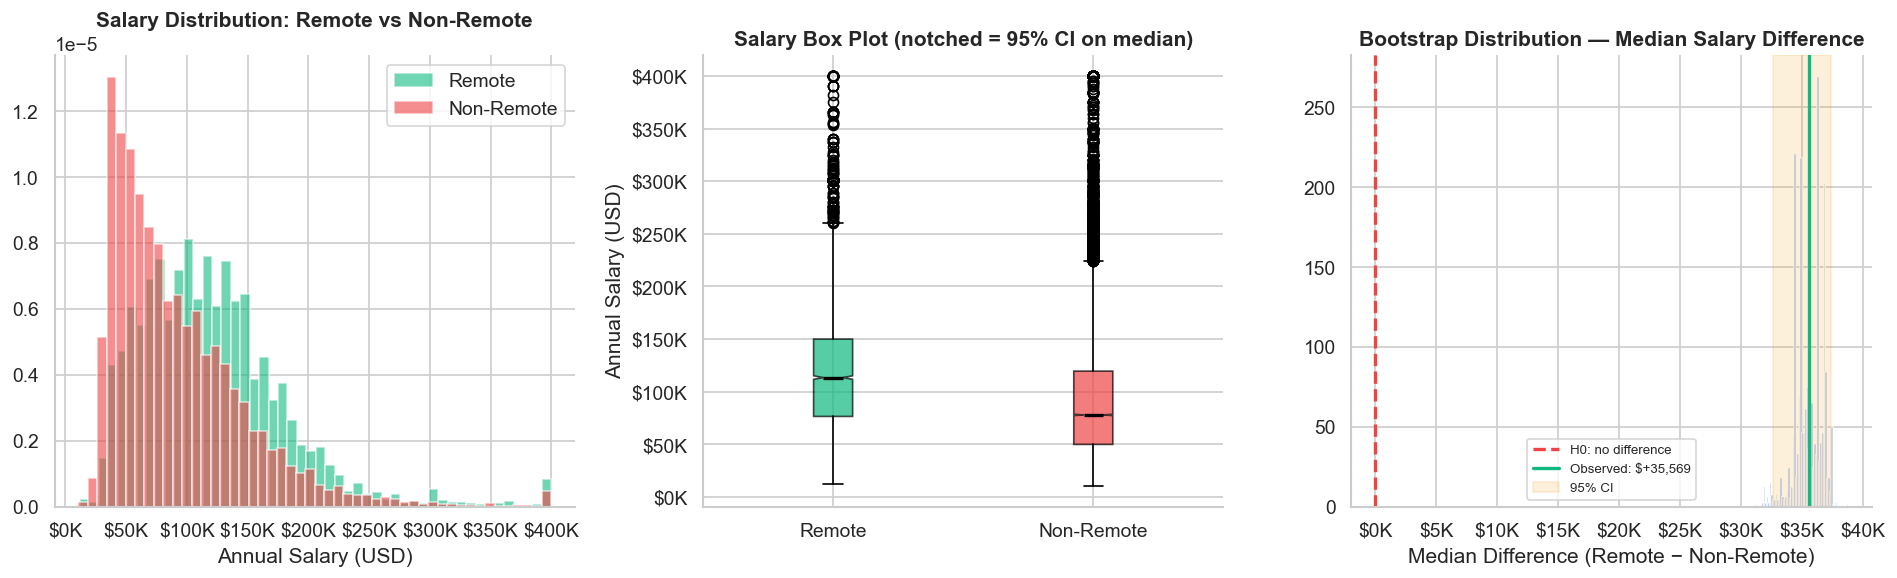

  p = 0.0000 | SIGNIFICANT ✅
  Effect size (Cohen's d): 0.4669


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution comparison
for label, data, color in [("Remote", group_remote, PALETTE_POS),
                             ("Non-Remote", group_non_remote, PALETTE_NEG)]:
    axes[0].hist(data.clip(upper=400_000), bins=50, alpha=0.6,
                 color=color, label=label, density=True)
axes[0].set_title("Salary Distribution: Remote vs Non-Remote", fontweight="bold")
axes[0].set_xlabel("Annual Salary (USD)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1000:.0f}K"))
axes[0].legend()

# Box plot
bp_data = [group_remote.clip(upper=400_000).values,
           group_non_remote.clip(upper=400_000).values]
bp = axes[1].boxplot(bp_data, labels=["Remote","Non-Remote"],
                     patch_artist=True, notch=True,
                     medianprops=dict(color="black", lw=2))
for patch, color in zip(bp["boxes"], [PALETTE_POS, PALETTE_NEG]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title("Salary Box Plot (notched = 95% CI on median)", fontweight="bold")
axes[1].set_ylabel("Annual Salary (USD)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1000:.0f}K"))

# Bootstrap distribution of median difference
axes[2].hist(bootstrap_diffs, bins=60, color=PALETTE_MAIN, alpha=0.8, edgecolor="white")
axes[2].axvline(0, color=PALETTE_NEG, lw=2, ls="--", label="H0: no difference")
axes[2].axvline(np.median(bootstrap_diffs), color=PALETTE_POS, lw=2,
                label=f"Observed: ${np.median(bootstrap_diffs):+,.0f}")
axes[2].axvspan(ci_low, ci_high, alpha=0.15, color=PALETTE_ACCENT, label="95% CI")
axes[2].set_title("Bootstrap Distribution — Median Salary Difference", fontweight="bold")
axes[2].set_xlabel("Median Difference (Remote − Non-Remote)")
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1000:.0f}K"))
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ab_test_exp1_remote_salary.png", bbox_inches="tight")
plt.show()

print(f"{'='*60}")
print(f"  p = {exp1_result['p_value']:.4f} | {'SIGNIFICANT ✅' if exp1_result['reject_h0'] else 'NOT SIGNIFICANT ❌'}")
print(f"  Effect size (Cohen's d): {exp1_result['cohens_d']:.4f}")

In [42]:
# ── EXPERIMENT 2: High-Skill-Count vs Low-Skill-Count Salary ──────────────────
# Hypothesis:
#   H0 : Salary jobs dengan banyak skill = salary jobs dengan sedikit skill
#   H1 : Salary jobs dengan banyak skill > salary jobs dengan sedikit skill
# Threshold : median skill count sebagai split point (data-driven)

EXP2_NAME = "High vs Low Skill Count — Salary Impact"

# Merge skill count per job onto postings
skill_count_df = (
    postings
    .merge(skill_freq_per_job[["job_id","unique_skill_count"]], on="job_id", how="left")
    .dropna(subset=["normalized_salary","unique_skill_count"])
    .query("normalized_salary > 10_000 and normalized_salary < 1_000_000")
)

# Data-driven threshold: median skill count
threshold = skill_count_df["unique_skill_count"].median()
group_high = skill_count_df[skill_count_df["unique_skill_count"] >  threshold]["normalized_salary"]
group_low  = skill_count_df[skill_count_df["unique_skill_count"] <= threshold]["normalized_salary"]

stat2, p2 = mannwhitneyu(group_high, group_low, alternative="greater")
d2 = (group_high.mean() - group_low.mean()) / skill_count_df["normalized_salary"].std()

np.random.seed(42)
boot2 = [
    np.median(np.random.choice(group_high, len(group_high), replace=True)) -
    np.median(np.random.choice(group_low,  len(group_low),  replace=True))
    for _ in range(2000)
]
ci2_low, ci2_high = np.percentile(boot2, [2.5, 97.5])

reject2 = p2 < ALPHA
print(f"{'='*60}")
print(f"  EXPERIMENT 2: {EXP2_NAME}")
print(f"{'='*60}")
print(f"  Skill count threshold (median): {threshold:.0f} skills")
print(f"  n_high_skill : {len(group_high):,}")
print(f"  n_low_skill  : {len(group_low):,}")
print(f"  Median high  : ${group_high.median():>10,.0f}")
print(f"  Median low   : ${group_low.median():>10,.0f}")
print(f"  Difference   : ${group_high.median() - group_low.median():>+,.0f}")
print(f"  95% CI       : [${ci2_low:+,.0f}, ${ci2_high:+,.0f}]")
print(f"  p-value      : {p2:.4f}")
print(f"  Cohen's d    : {d2:.4f}")
print(f"\n  Decision: {'✅ REJECT H0' if reject2 else '❌ FAIL TO REJECT H0'}")
print(f"  Conclusion: High-skill jobs {'DO' if reject2 else 'do NOT'} offer significantly higher salaries.")

exp2_result = {
    "experiment": EXP2_NAME, "test": "Mann-Whitney U",
    "threshold": threshold, "n_a": len(group_high), "n_b": len(group_low),
    "median_a": group_high.median(), "median_b": group_low.median(),
    "stat": stat2, "p_value": p2, "alpha": ALPHA,
    "reject_h0": reject2, "cohens_d": d2, "ci_low": ci2_low, "ci_high": ci2_high,
}

  EXPERIMENT 2: High vs Low Skill Count — Salary Impact
  Skill count threshold (median): 2 skills
  n_high_skill : 5,098
  n_low_skill  : 29,978
  Median high  : $    88,400
  Median low   : $    81,646
  Difference   : $+6,754
  95% CI       : [$+5,000, $+9,500]
  p-value      : 0.0000
  Cohen's d    : 0.1235

  Decision: ✅ REJECT H0
  Conclusion: High-skill jobs DO offer significantly higher salaries.


  EXPERIMENT 3: Remote Rate × Experience Level (Chi-Square)

  Contingency Table:


"Remote (0=No, 1=Yes)",0,1
Experience Level,,
Associate,8650,1176
Director,3076,670
Entry level,34761,1947
Executive,993,229
Internship,1359,90
Mid-Senior level,35112,6377



  Chi-Square  : 2304.8563
  Degrees of freedom: 5
  p-value     : 0.000000
  Cramér's V  : 0.1562  (small)

  Decision: ✅ REJECT H0
  Conclusion: Remote rate IS significantly associated with experience level.


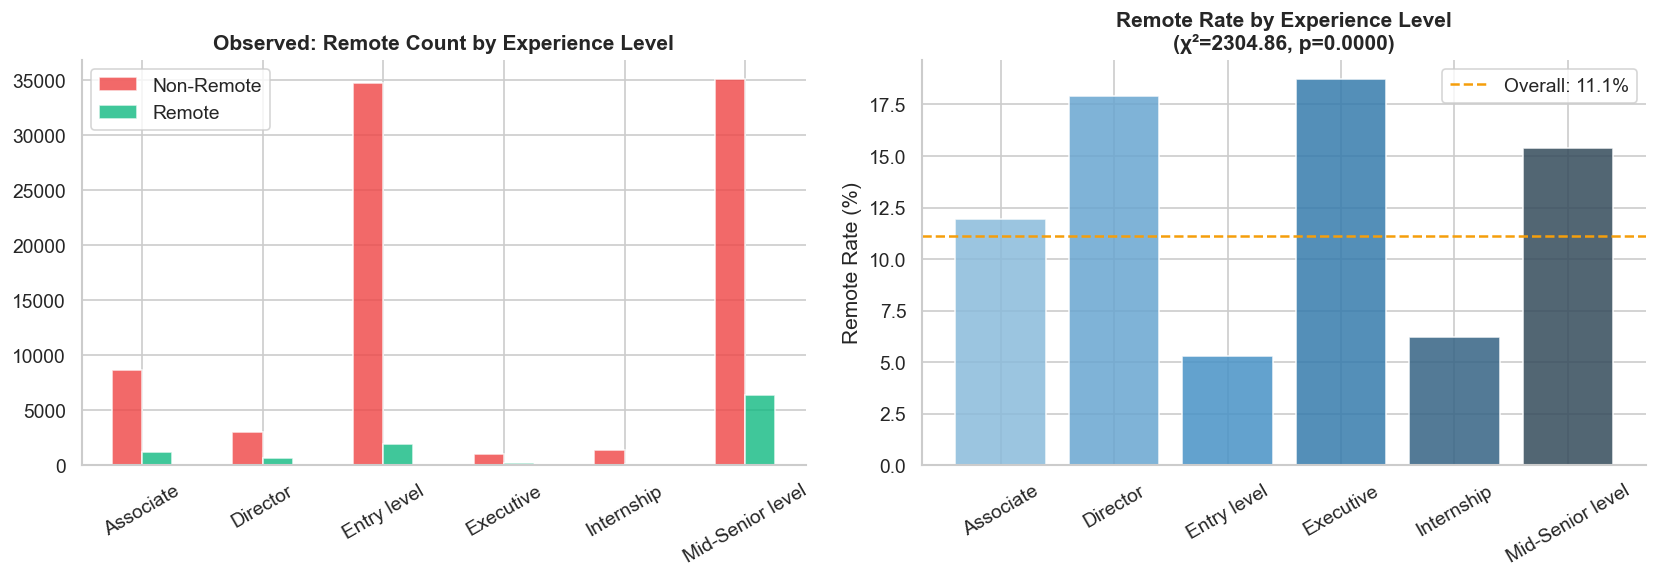

In [43]:
# ── EXPERIMENT 3: Remote Rate × Experience Level (Chi-Square) ─────────────────
# Hypothesis:
#   H0 : Remote rate independen dari experience level
#   H1 : Remote rate berbeda signifikan antar experience level
# Method : Chi-Square Test of Independence

EXP3_NAME = "Remote Rate × Experience Level (Chi-Square)"

exp_remote = (
    postings
    .query("formatted_experience_level != 'Not Specified'")
    [["formatted_experience_level","remote_allowed"]]
    .dropna()
)
exp_remote["remote_allowed"] = exp_remote["remote_allowed"].astype(int)

# Contingency table
contingency = pd.crosstab(
    exp_remote["formatted_experience_level"],
    exp_remote["remote_allowed"],
    rownames=["Experience Level"],
    colnames=["Remote (0=No, 1=Yes)"]
)

chi2, p3, dof, expected = chi2_contingency(contingency)

# Cramér's V — effect size for chi-square
n_total = contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n_total * (min(contingency.shape) - 1)))

reject3 = p3 < ALPHA
print(f"{'='*60}")
print(f"  EXPERIMENT 3: {EXP3_NAME}")
print(f"{'='*60}")
print(f"\n  Contingency Table:")
display(contingency)
print(f"\n  Chi-Square  : {chi2:.4f}")
print(f"  Degrees of freedom: {dof}")
print(f"  p-value     : {p3:.6f}")
print(f"  Cramér's V  : {cramers_v:.4f}  ({'negligible' if cramers_v<0.1 else 'small' if cramers_v<0.3 else 'medium' if cramers_v<0.5 else 'large'})")
print(f"\n  Decision: {'✅ REJECT H0' if reject3 else '❌ FAIL TO REJECT H0'}")
print(f"  Conclusion: Remote rate {'IS' if reject3 else 'is NOT'} significantly associated with experience level.")

exp3_result = {
    "experiment": EXP3_NAME, "test": "Chi-Square",
    "chi2": chi2, "dof": dof, "p_value": p3, "alpha": ALPHA,
    "reject_h0": reject3, "cramers_v": cramers_v,
}

# Visualize observed vs expected
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contingency.plot(kind="bar", ax=axes[0], color=[PALETTE_NEG, PALETTE_POS],
                 alpha=0.8, edgecolor="white")
axes[0].set_title("Observed: Remote Count by Experience Level", fontweight="bold")
axes[0].set_xlabel(""); axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(["Non-Remote","Remote"])

# Remote rate per experience level
remote_rate_exp = exp_remote.groupby("formatted_experience_level")["remote_allowed"].mean().mul(100)
axes[1].bar(remote_rate_exp.index, remote_rate_exp.values,
            color=sns.color_palette(PALETTE_SEQ, len(remote_rate_exp)), alpha=0.85)
axes[1].axhline(exp_remote["remote_allowed"].mean()*100, color=PALETTE_ACCENT,
                ls="--", lw=1.5, label=f"Overall: {exp_remote['remote_allowed'].mean()*100:.1f}%")
axes[1].set_title(f"Remote Rate by Experience Level\n(χ²={chi2:.2f}, p={p3:.4f})", fontweight="bold")
axes[1].set_ylabel("Remote Rate (%)"); axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()